
  NIFTY 50 QUANT SYSTEM v6.0  |  Walk-Forward  |  UNiverse Capital

[DATA] Fetching ^NSEI (2016-02-15 → 2026-04-13) ...
[DATA] Live: 2501 rows ✓
[DATA] (2473, 5) | 2016-02-15 → 2026-04-10
Price              Open         High          Low        Close  Volume
Date                                                                  
2016-02-15  7057.350098  7182.799805  7056.799805  7162.950195  354200
2016-02-16  7201.250000  7204.649902  7037.700195  7048.250000  253800
2016-02-17  7058.850098  7123.700195  6960.649902  7108.450195  260000
2016-02-18  7177.399902  7215.100098  7127.850098  7191.750000  246700
2016-02-19  7170.549805  7226.850098  7145.950195  7210.750000  192300

[FEATURE] Computing Hurst (DFA 90d) ...
[PIPELINE] Features: (2353, 28)

[SPLIT] Train: 2016-08-10 → 2024-11-28 (2016 days / 8yr)
[SPLIT] Test:  2024-11-29 → 2026-04-10 (337 days / 1.3yr — PURE OOS)


[CALIBRATE] Training on 2016 rows (2016-08-10 → 2024-11-28) ...
[CALIBRATE] pvol_thresh    = 0.01212
[CALIBRATE]

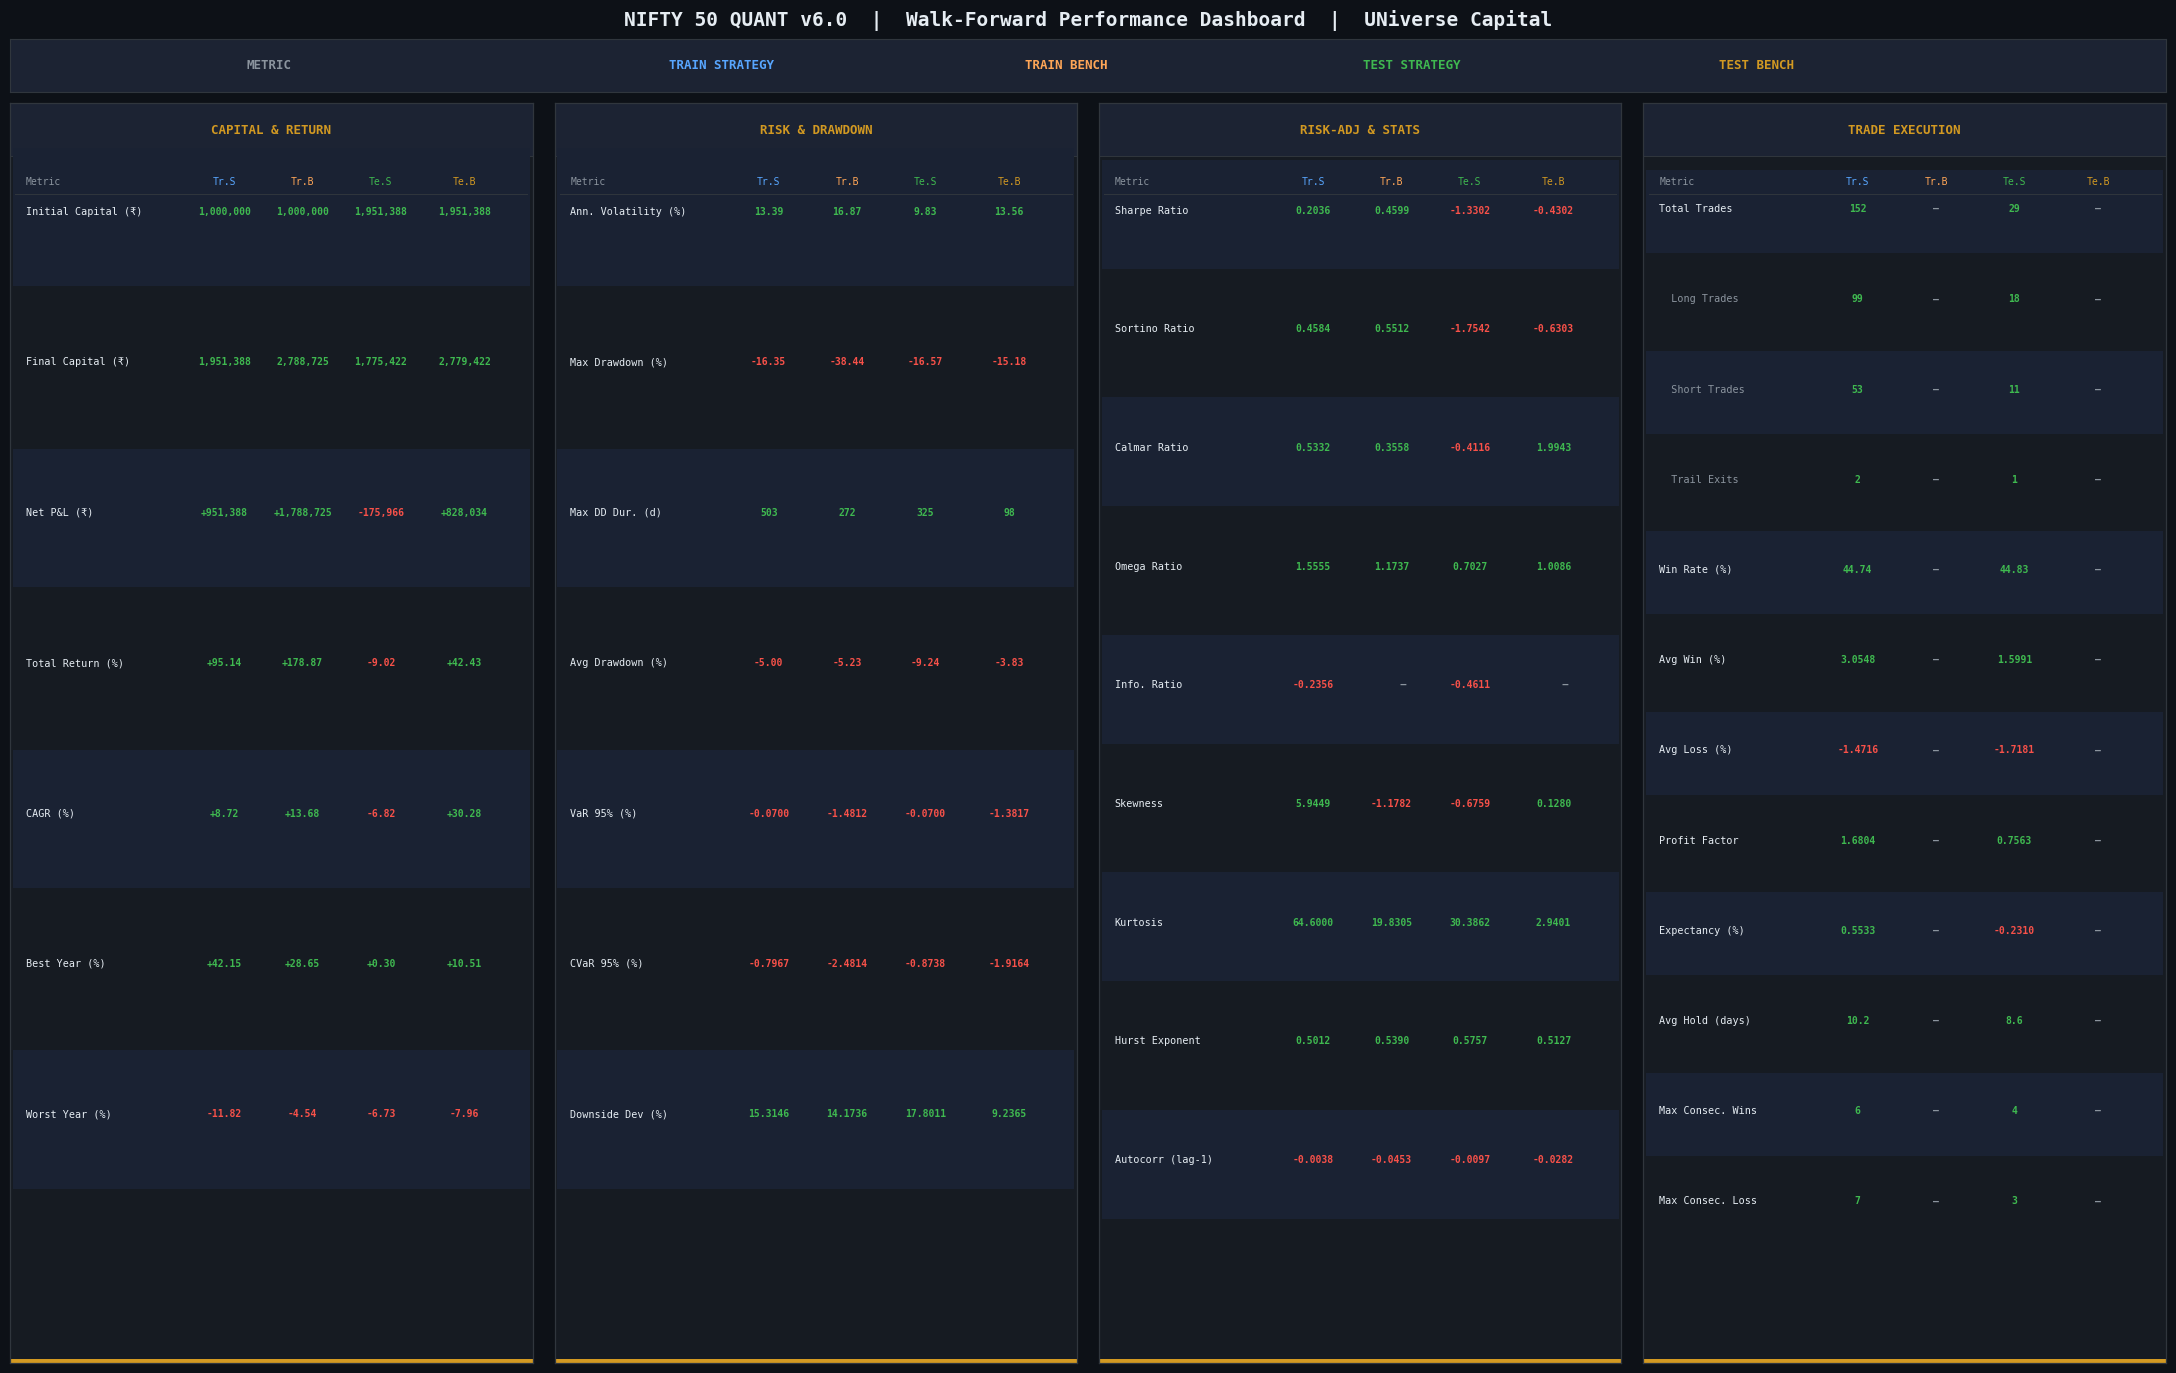

[PLOT 0] Dashboard ✓


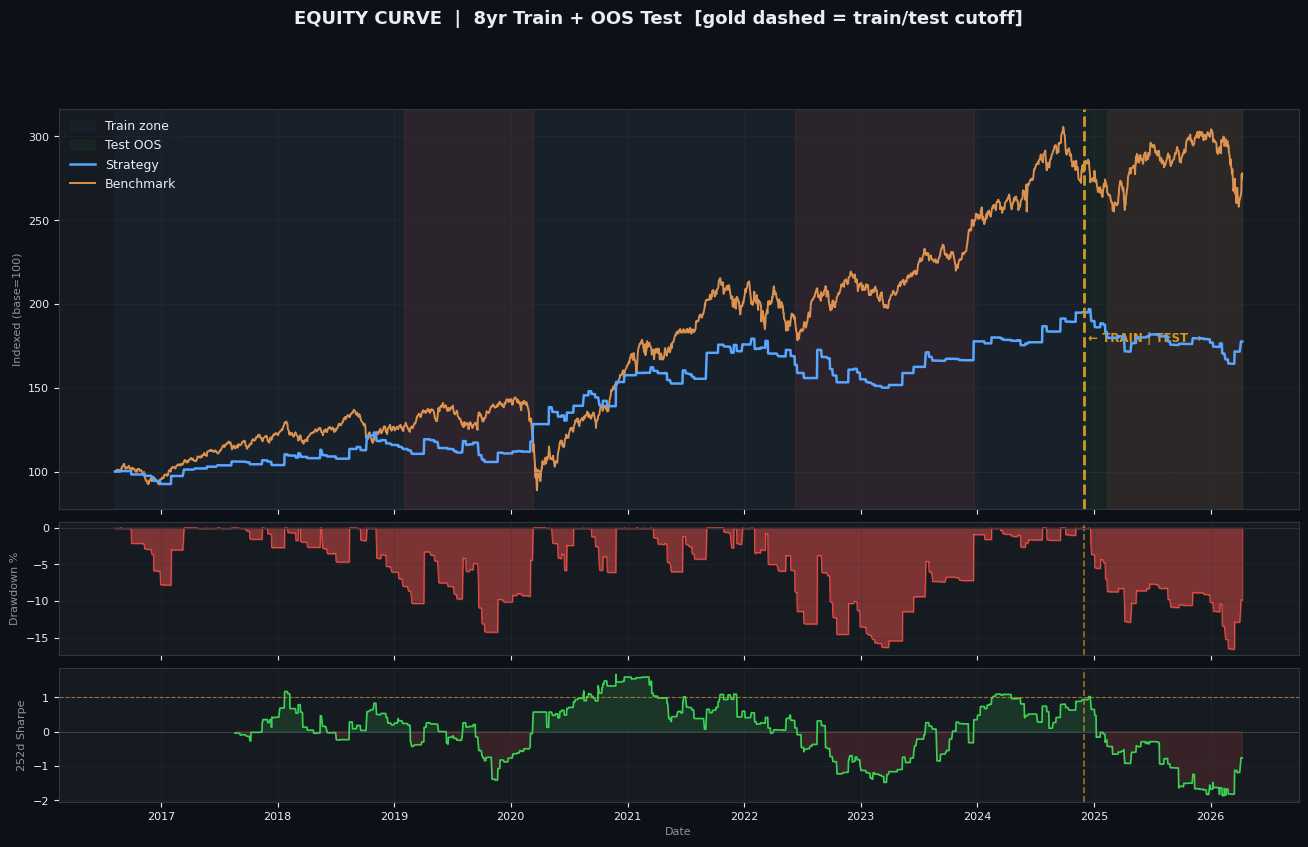

[PLOT 1] Equity Curve ✓


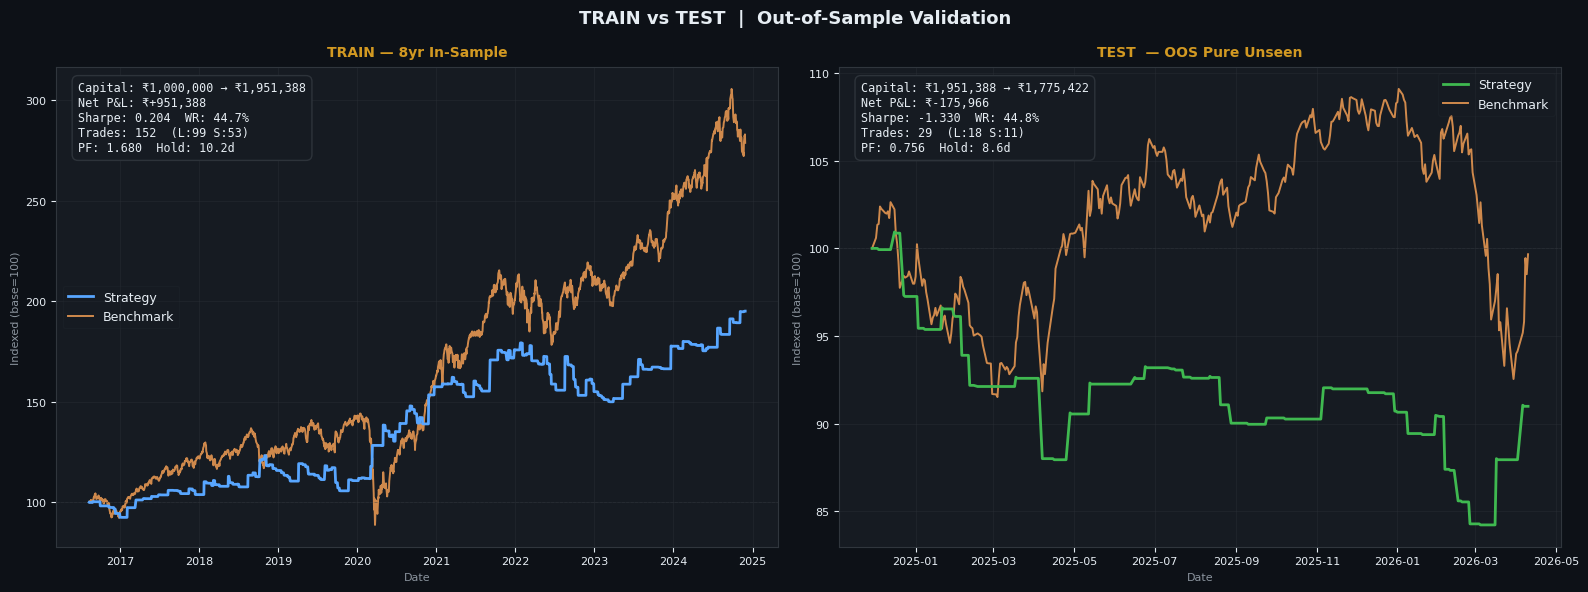

[PLOT 2] Train vs Test ✓


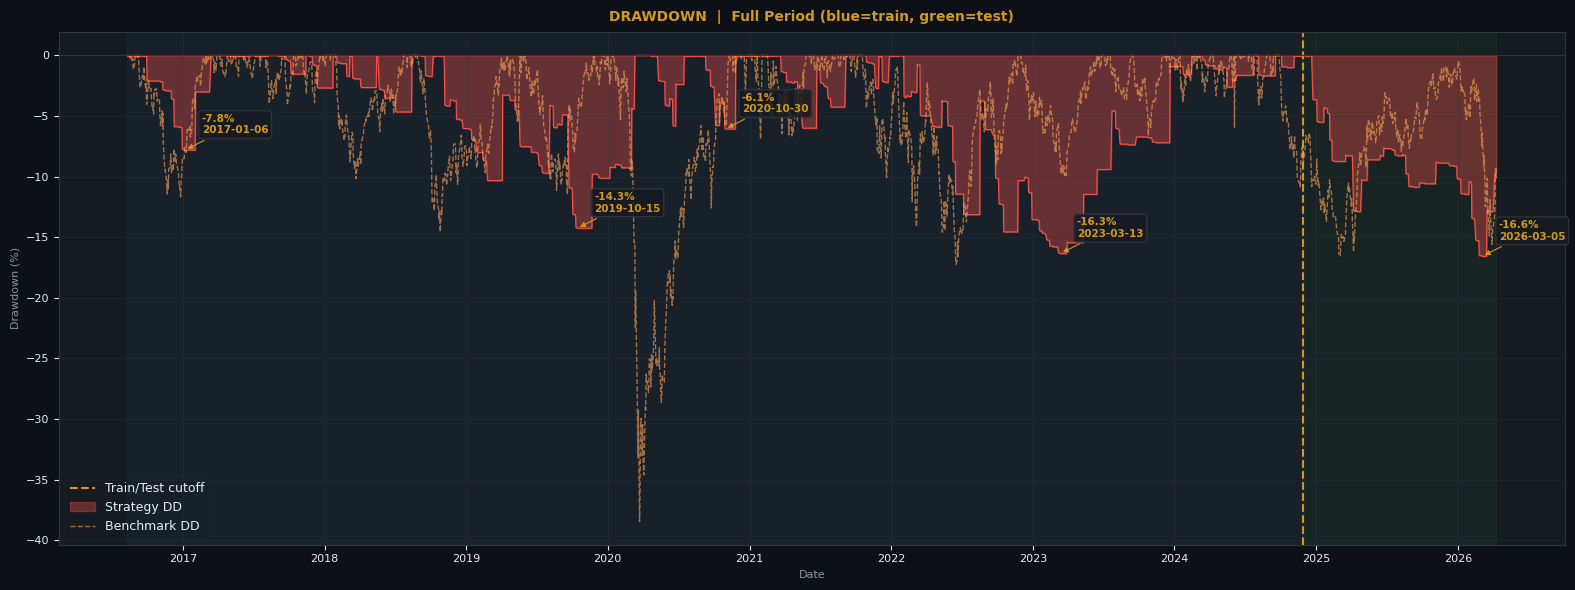

[PLOT 3] Drawdown ✓


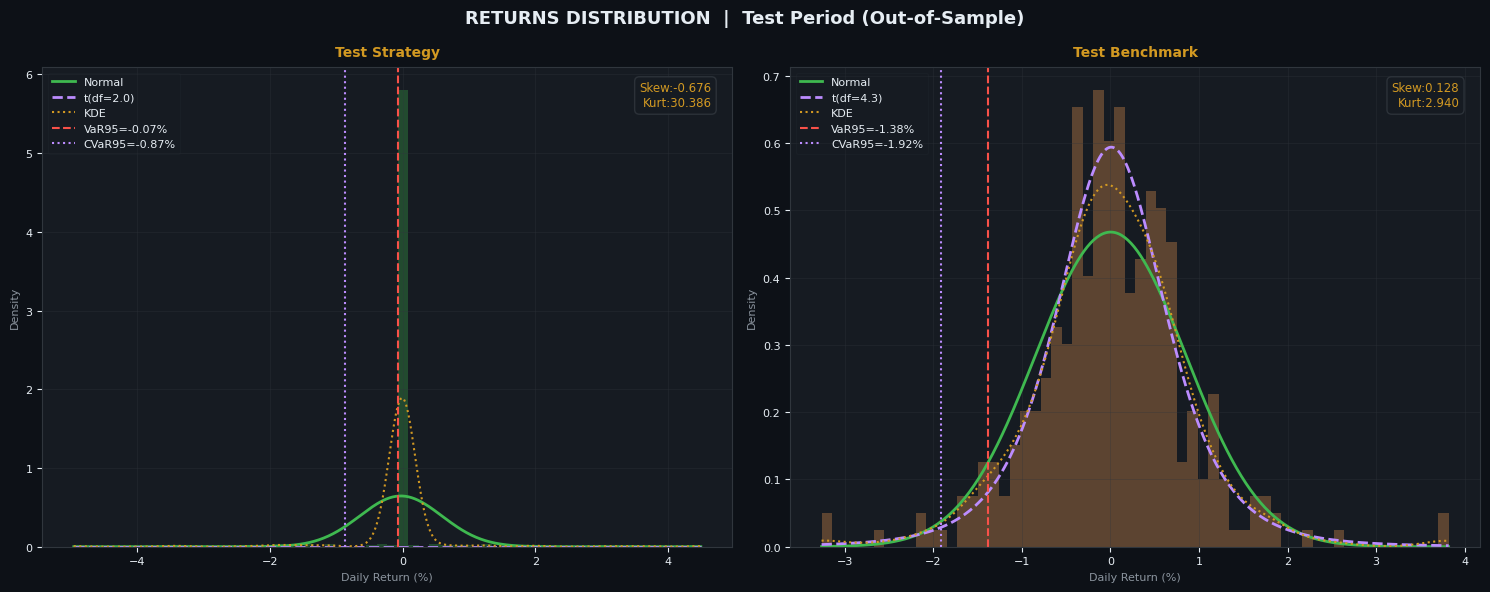

[PLOT 4] Distribution ✓


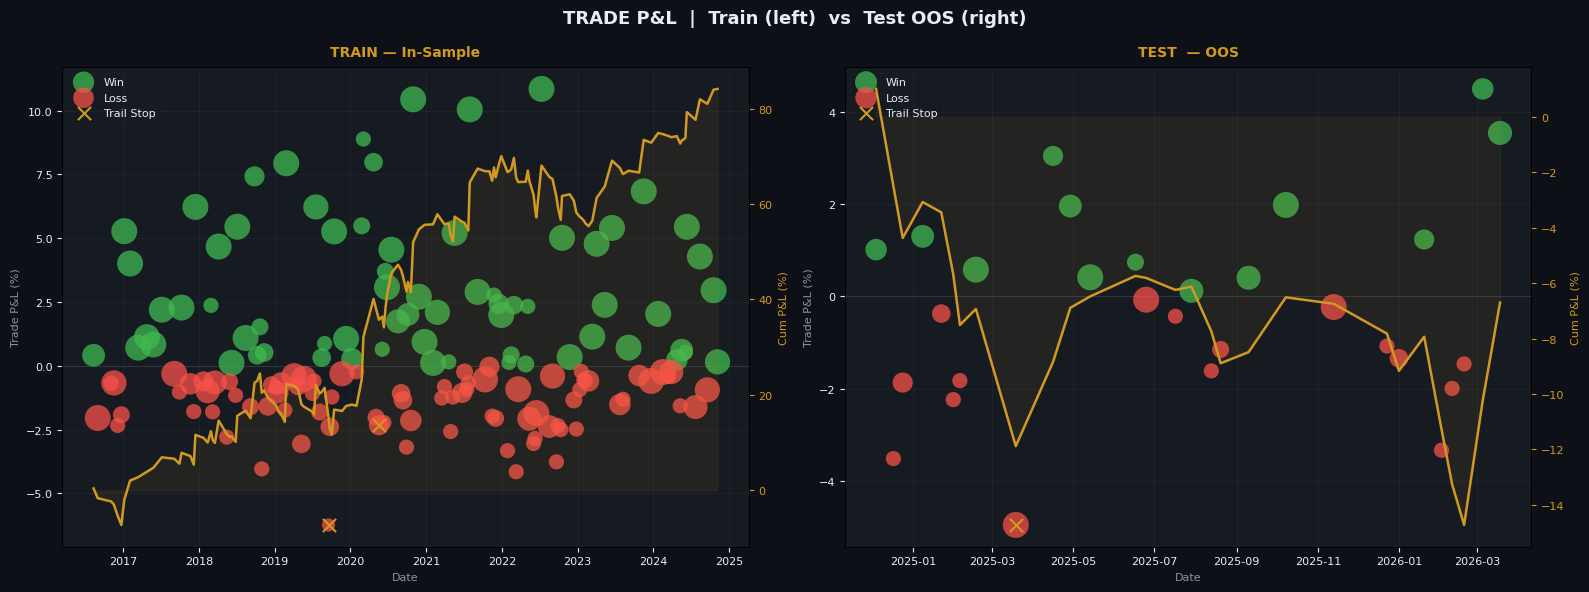

[PLOT 5] Trade P&L ✓


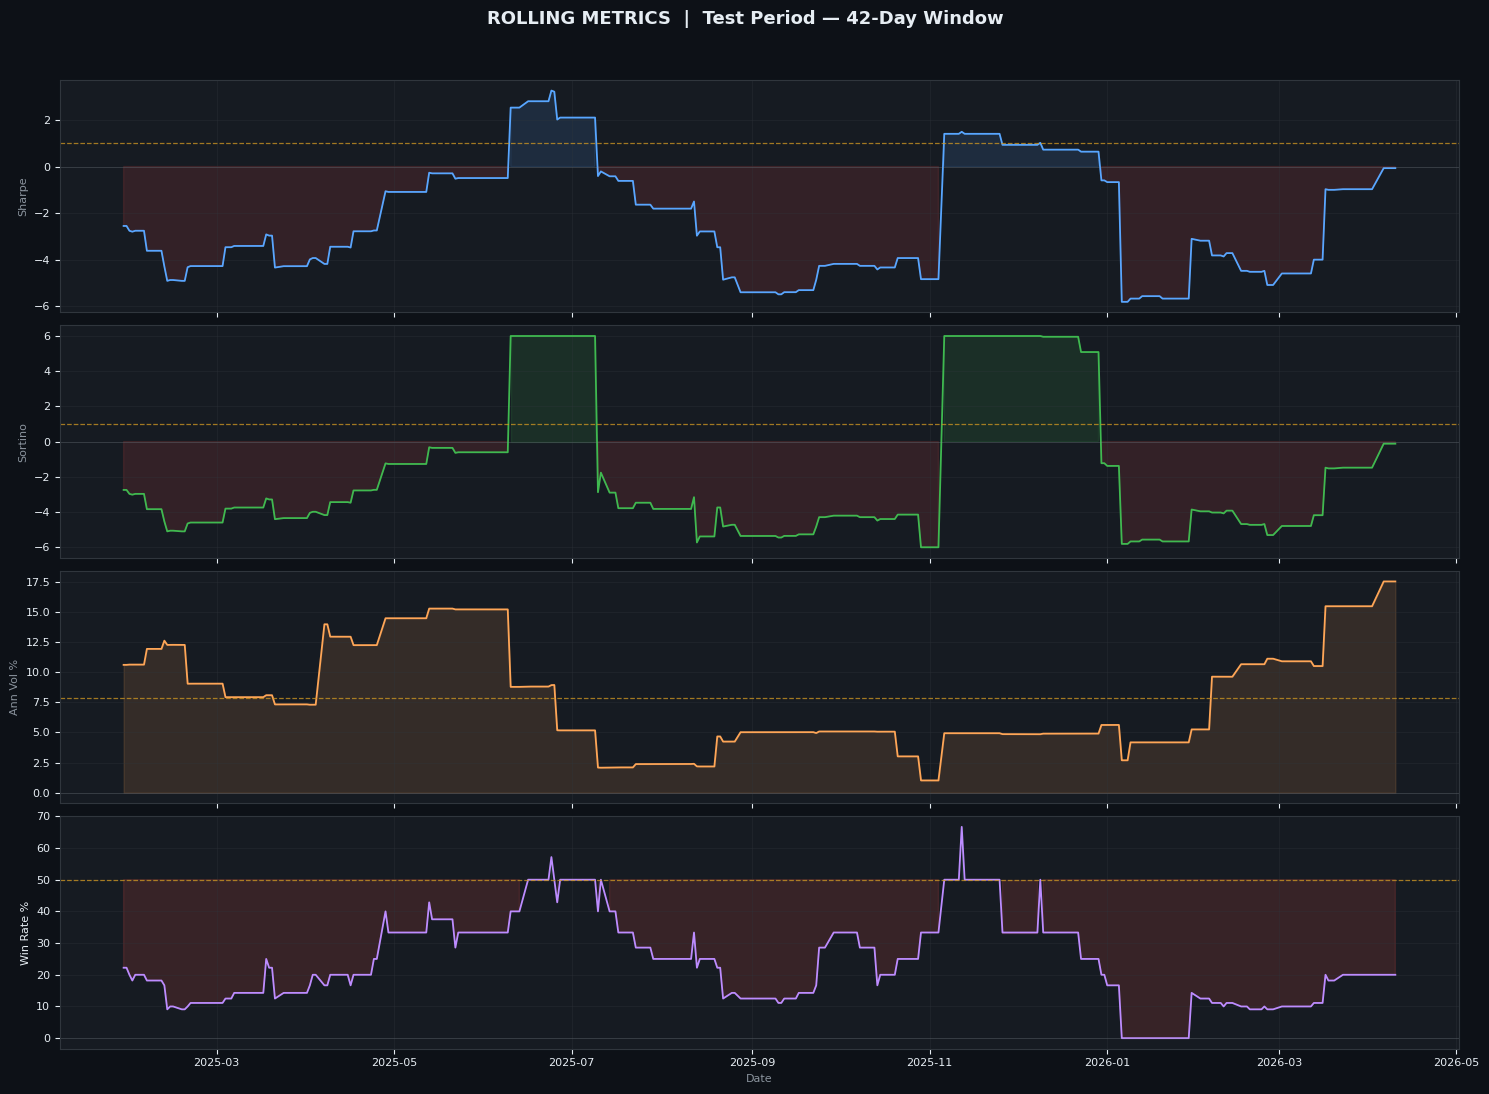

[PLOT 6] Rolling Metrics ✓


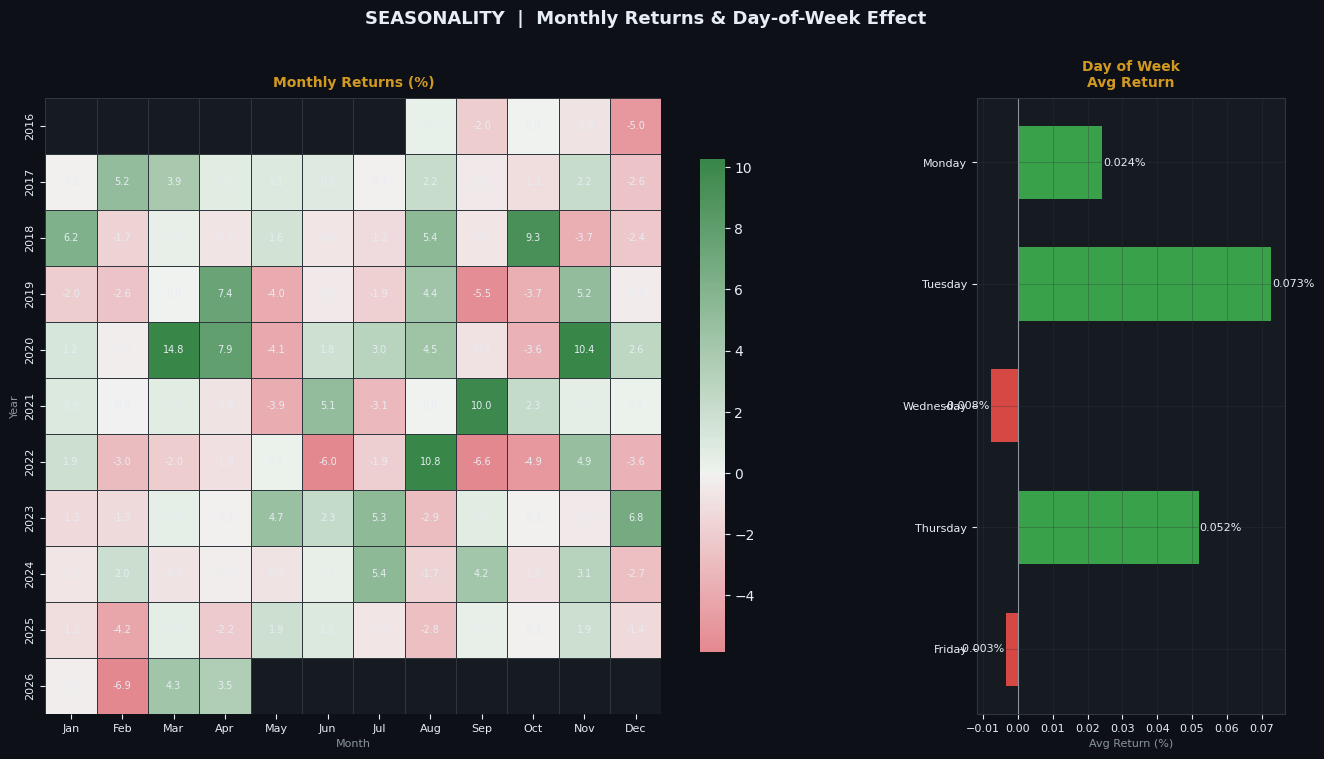

[PLOT 7] Heatmaps ✓

[MC-OOS] P5 : ₹   1,459,950
[MC-OOS] P50: ₹   1,771,158
[MC-OOS] P95: ₹   2,138,946


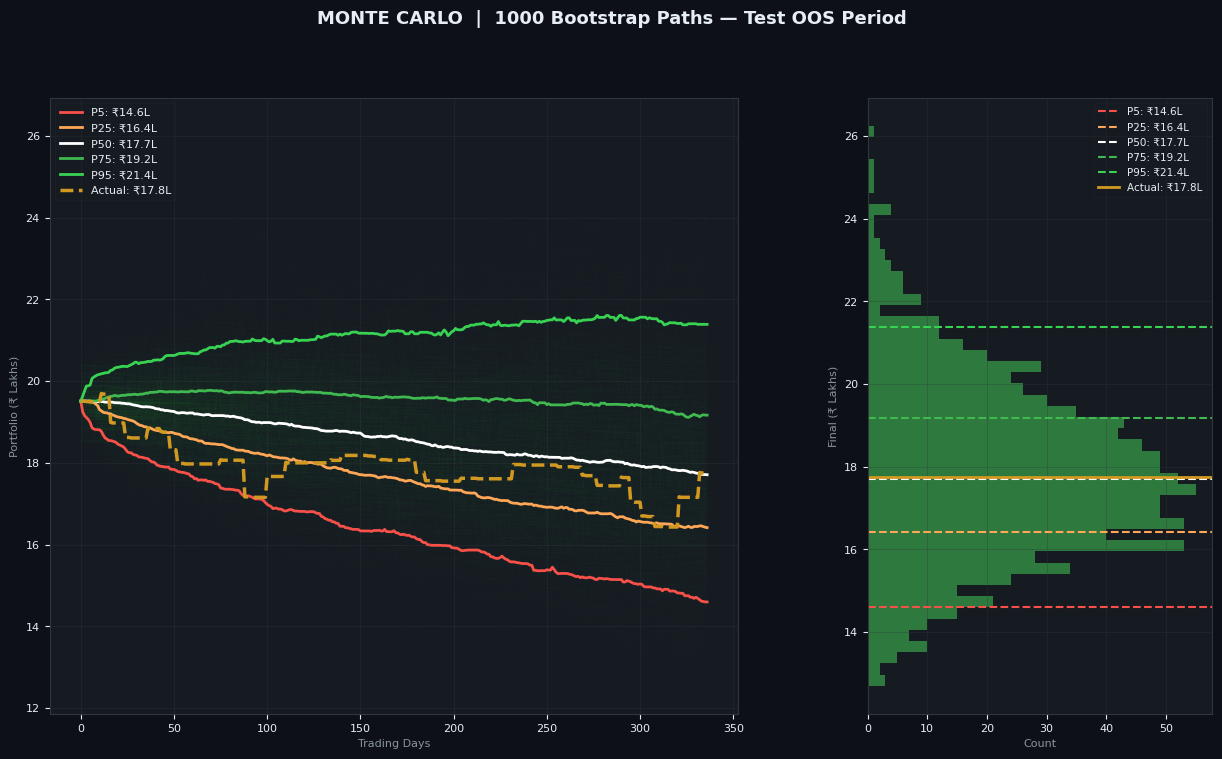

[PLOT 8] Monte Carlo ✓

  PIPELINE COMPLETE  |  v6.0 Walk-Forward OOS



In [1]:
"""
Nifty 50 Quant System v6.0 — UNiverse Capital
==============================================
Key fixes over v5:
  - Composite SCORE approach (weighted sum) replaces AND-gate
    → 5 conditions AND-gated was blocking 93% of days
  - Always tries to be long when trend is positive (high market exposure)
  - Shorts only in confirmed crash regime (very rare)
  - Trailing stop + time exit preserved
  - Metrics table includes Initial Capital, Final Capital, Net P&L
  - Walk-forward: 8yr train calibrate → 2yr pure OOS
Run: python model.py
"""

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import yfinance as yf
from datetime import datetime, timedelta

np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
TICKER          = "^NSEI"
INITIAL_CAPITAL = 1_000_000
TC              = 0.0005
SLIPPAGE        = 0.0002
RISK_FREE       = 0.065
TRADING_DAYS    = 252
TRAIN_YEARS     = 8
KELLY_CAP       = 2.0
MIN_HOLD        = 4
MAX_HOLD        = 25
TRAIL_STOP      = 0.07       # 7% trailing stop

BG="#0D1117"; PANEL_BG="#161B22"; BORDER="#30363D"; TEXT="#E6EDF3"
MUTED="#8B949E"; ACCENT="#58A6FF"; GREEN="#3FB950"; RED="#F85149"
GOLD="#D29922"; PURPLE="#BC8CFF"; ORANGE="#FFA657"; CYAN="#39D353"


# ─────────────────────────────────────────────────────────────────────────────
# DATA
# ─────────────────────────────────────────────────────────────────────────────
def _synthetic(start, end):
    print("[DATA] Using calibrated synthetic Nifty 50 ...")
    am,av,ar = 0.13,0.175,0.08
    bdays=pd.bdate_range(start,end); n=len(bdays)
    dt=1/TRADING_DAYS; sd=av*np.sqrt(dt)
    eps=np.random.normal(0,1,n); ae=np.zeros(n); ae[0]=eps[0]
    for i in range(1,n): ae[i]=ar*ae[i-1]+eps[i]*np.sqrt(1-ar**2)
    jmp=np.where(np.random.rand(n)<0.015,np.random.normal(-0.02,0.04,n),0)
    lr=am*dt-0.5*av**2*dt+sd*ae+jmp
    C=8000*np.exp(np.cumsum(lr))
    iv=av*np.sqrt(dt)*np.random.uniform(0.5,2,n)
    O=C*np.exp(np.random.normal(0,iv*0.3,n))
    H=np.maximum(O,C)*np.exp(np.abs(np.random.normal(0,iv*0.5,n)))
    L=np.minimum(O,C)*np.exp(-np.abs(np.random.normal(0,iv*0.5,n)))
    V=(200_000_000*np.random.lognormal(0,0.5,n)).astype(int)
    df=pd.DataFrame({"Open":O,"High":H,"Low":L,"Close":C,"Volume":V},index=bdays)
    df["High"]=df[["Open","High","Close"]].max(axis=1)
    df["Low"] =df[["Open","Low","Close"]].min(axis=1)
    return df.round(2)


def download_data():
    end=datetime.today(); start=end-timedelta(days=365*10+60)
    print(f"[DATA] Fetching {TICKER} ({start.date()} → {end.date()}) ...")
    df=pd.DataFrame()
    try:
        raw=yf.download(TICKER,start=start.strftime("%Y-%m-%d"),
                        end=end.strftime("%Y-%m-%d"),interval="1d",progress=False)
        if isinstance(raw.columns,pd.MultiIndex): raw.columns=raw.columns.get_level_values(0)
        raw=raw[["Open","High","Low","Close","Volume"]].dropna()
        if len(raw)>500: df=raw.copy(); print(f"[DATA] Live: {len(df)} rows ✓")
        else: raise ValueError("Too few rows")
    except Exception as e:
        print(f"[DATA] Live unavailable ({e})")
        df=_synthetic(start,end)
    df.dropna(inplace=True)
    df.index=pd.to_datetime(df.index)
    df=df[df["Volume"]>0].sort_index()
    print(f"[DATA] {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")
    print(df.head().to_string()); print()
    df["log_ret"]=np.log(df["Close"]/df["Close"].shift(1))
    return df


# ─────────────────────────────────────────────────────────────────────────────
# FEATURES
# ─────────────────────────────────────────────────────────────────────────────
def hurst_dfa(series):
    n=len(series)
    if n<20: return 0.5
    try:
        x=np.cumsum(series-series.mean())
        scales=np.unique(np.logspace(np.log10(4),np.log10(n//4),14).astype(int))
        flucts=[]
        for s in scales:
            ns=n//s
            if ns<2: continue
            f2=[]
            for k in range(ns):
                seg=x[k*s:(k+1)*s]; t=np.arange(s)
                trend=np.polyval(np.polyfit(t,seg,1),t)
                f2.append(np.mean((seg-trend)**2))
            flucts.append(np.sqrt(np.mean(f2)))
        if len(flucts)<4: return 0.5
        h,_=np.polyfit(np.log(scales[:len(flucts)]),np.log(flucts),1)
        return float(np.clip(h,0.05,0.95))
    except: return 0.5


def compute_features(df):
    """Strictly causal features — only past data used at each timestep."""
    f=df.copy()
    O,H,L,C,V=f["Open"],f["High"],f["Low"],f["Close"],f["Volume"]
    pC=C.shift(1)

    # Multi-period momentum (core)
    for d in [5,10,20,40,60,120]:
        f[f"ret_{d}d"]=C/C.shift(d)-1

    # Trend breadth — fraction of up-days
    for w in [10,20,40]:
        f[f"upfrac_{w}"]=(f["log_ret"].rolling(w).apply(lambda x:(x>0).mean(),raw=True))

    # Candle structure
    f["body_ratio"]=np.abs(C-O)/(H-L+1e-9)
    f["lower_wick"]=(np.minimum(O,C)-L)/(H-L+1e-9)
    f["upper_wick"]=(H-np.maximum(O,C))/(H-L+1e-9)
    f["daily_ret"]=(C-O)/(O+1e-9)
    f["gap"]=(O-pC)/(pC+1e-9)

    # Volatility
    f["rvol10"]=f["log_ret"].rolling(10).std()*np.sqrt(TRADING_DAYS)
    f["rvol20"]=f["log_ret"].rolling(20).std()*np.sqrt(TRADING_DAYS)
    f["pvol"]  =np.sqrt((1/(4*np.log(2)))*np.log(H/L)**2)

    # Volume surge
    vm=V.rolling(10).mean(); vs=V.rolling(10).std()
    f["vol_z"]=(V-vm)/(vs+1e-9)

    # Range position
    f["range20"]=(C-C.rolling(20).min())/(C.rolling(20).max()-C.rolling(20).min()+1e-9)
    f["range60"]=(C-C.rolling(60).min())/(C.rolling(60).max()-C.rolling(60).min()+1e-9)

    # Momentum acceleration (20d momentum change over 5 days)
    f["accel20"]=f["ret_20d"]-f["ret_20d"].shift(5)

    # Rolling Hurst 90d
    print("[FEATURE] Computing Hurst (DFA 90d) ...")
    lr_arr=f["log_ret"].values; h_arr=np.full(len(f),0.5)
    for i in range(90,len(f)): h_arr[i]=hurst_dfa(lr_arr[i-90:i])
    f["hurst"]=h_arr

    f.dropna(inplace=True)
    return f


# ─────────────────────────────────────────────────────────────────────────────
# CALIBRATION — learn signal weights & thresholds from train only
# ─────────────────────────────────────────────────────────────────────────────
def _long_score(f: pd.DataFrame) -> pd.Series:
    """
    Composite long score — weighted sum of momentum/breadth/candle factors.
    Higher = more bullish. Calibration only tunes the threshold, not these weights.
    """
    sc = pd.Series(0.0, index=f.index)

    # Momentum contributions (clipped to prevent single outlier dominating)
    sc += np.clip(f["ret_20d"] / 0.02, -4, 4) * 2.5   # 20d — primary
    sc += np.clip(f["ret_60d"] / 0.05, -3, 3) * 1.5   # 60d — regime
    sc += np.clip(f["ret_10d"] / 0.01, -3, 3) * 1.0   # 10d — recent
    sc += np.clip(f["ret_40d"] / 0.03, -2, 2) * 0.8   # 40d — medium
    sc += np.clip(f["ret_5d"]  / 0.008,-2, 2) * 0.5   # 5d  — short pulse
    sc += np.clip(f["accel20"] / 0.01, -2, 2) * 0.7   # acceleration

    # Breadth
    sc += (f["upfrac_10"] - 0.5) * 3.0   # ranges ~[-1.5, +1.5]
    sc += (f["upfrac_20"] - 0.5) * 2.0
    sc += (f["range60"]   - 0.5) * 1.5   # price position in 60d range

    # Candle
    sc += np.where(f["body_ratio"] > 0.6, np.sign(f["daily_ret"]) * 0.4, 0.0)
    sc += np.where(f["vol_z"] > 1.5, np.sign(f["daily_ret"]) * 0.5, 0.0)

    return sc


def _short_score(f: pd.DataFrame) -> pd.Series:
    """Composite short score — inverse of long score with tighter weights."""
    sc = pd.Series(0.0, index=f.index)
    sc += np.clip(-f["ret_20d"] / 0.02, -4, 4) * 2.5
    sc += np.clip(-f["ret_60d"] / 0.05, -3, 3) * 1.5
    sc += np.clip(-f["ret_10d"] / 0.01, -3, 3) * 1.0
    sc += (0.5 - f["upfrac_10"]) * 3.0
    sc += (0.5 - f["upfrac_20"]) * 2.0
    sc += (0.5 - f["range60"])   * 1.5
    sc += np.where(f["hurst"] > 0.55, 0.5, 0.0)  # only short in trending down
    return sc


def calibrate(train: pd.DataFrame) -> dict:
    """Calibrate signal thresholds on train data only. Nothing touches test."""
    print(f"\n[CALIBRATE] Training on {len(train)} rows "
          f"({train.index[0].date()} → {train.index[-1].date()}) ...")

    pvol_thresh = np.nanpercentile(train["pvol"].values, 93)
    rvol_mean   = train["rvol20"].mean()
    lr = train["log_ret"].dropna().values
    wm = lr > 0
    aw = lr[wm].mean() if wm.sum() > 0 else 0.01
    al = np.abs(lr[~wm]).mean() if (~wm).sum() > 0 else 0.01
    kelly_f = float(np.clip(wm.mean()/(al+1e-9)-(1-wm.mean())/(aw+1e-9), 0.3, KELLY_CAP))

    # Compute composite scores on train
    ls = _long_score(train)
    ss = _short_score(train)

    # 5-day forward return for threshold search
    fwd5 = train["log_ret"].shift(-1).rolling(5).sum().shift(-4)

    # Long threshold: find score level where 5d forward Sharpe is maximised
    # Target: ~40-60% of trading days should have a long signal
    best_tl = 2.0; best_sh = -np.inf
    for thr in np.arange(0.5, 8.0, 0.25):
        mask = ls >= thr
        pct  = mask.mean()
        if pct < 0.15 or pct > 0.70: continue   # keep 15-70% market exposure
        fr = fwd5[mask].dropna()
        if len(fr) < 50: continue
        sh = fr.mean() / (fr.std() + 1e-9) * np.sqrt(252/5)
        if sh > best_sh: best_sh = sh; best_tl = thr

    # Short threshold: very high bar — only crash regime
    # Target: <5% of days
    best_ts = 6.0; best_sh_s = -np.inf
    for thr in np.arange(3.0, 10.0, 0.5):
        mask = ss >= thr
        pct  = mask.mean()
        if pct < 0.005 or pct > 0.08: continue
        fr = (-fwd5[mask]).dropna()
        if len(fr) < 10: continue
        sh = fr.mean() / (fr.std() + 1e-9) * np.sqrt(252/5)
        if sh > best_sh_s: best_sh_s = sh; best_ts = thr

    params = dict(pvol_thresh=pvol_thresh, rvol_mean=rvol_mean,
                  kelly_f=kelly_f, thresh_long=best_tl, thresh_short=best_ts)

    pct_long  = (ls >= best_tl).mean() * 100
    pct_short = (ss >= best_ts).mean() * 100
    print(f"[CALIBRATE] pvol_thresh    = {pvol_thresh:.5f}")
    print(f"[CALIBRATE] kelly_f        = {kelly_f:.4f}")
    print(f"[CALIBRATE] thresh_long    = {best_tl:.2f}  "
          f"→ {pct_long:.1f}% of train days are long signals")
    print(f"[CALIBRATE] thresh_short   = {best_ts:.2f}  "
          f"→ {pct_short:.1f}% of train days are short signals")
    print(f"[CALIBRATE] rvol_mean      = {rvol_mean:.4f}\n")
    return params


# ─────────────────────────────────────────────────────────────────────────────
# SIGNAL GENERATION — apply frozen params to any dataset
# ─────────────────────────────────────────────────────────────────────────────
def generate_signals(f: pd.DataFrame, params: dict) -> pd.DataFrame:
    """
    Apply calibrated composite thresholds.
    Long  : long_score  >= thresh_long  AND not extreme vol
    Short : short_score >= thresh_short AND not extreme vol
    Flat  : everything else
    """
    s = f.copy()
    tl  = params["thresh_long"]
    ts  = params["thresh_short"]
    pth = params["pvol_thresh"]
    rvm = params["rvol_mean"]
    kf  = params["kelly_f"]

    ls = _long_score(s)
    ss = _short_score(s)

    long_sig  = (ls >= tl) & (s["pvol"] <= pth)
    short_sig = (ss >= ts) & (s["pvol"] <= pth)

    raw = np.where(long_sig, 1.0, np.where(short_sig, -1.0, 0.0))

    # Size: stronger score → more conviction → larger size
    score_strength = np.where(raw == 1,  ls / (tl + 1e-9),
                     np.where(raw == -1, ss / (ts + 1e-9), 0.0))
    score_strength = np.clip(score_strength, 0.5, 2.0)

    rv_norm = (s["rvol20"] / (rvm + 1e-9)).clip(lower=0.3, upper=3.0)
    base    = kf / rv_norm
    s["signal"]   = raw
    s["pos_size"] = (base * score_strength * np.abs(raw)).clip(upper=KELLY_CAP)
    return s


# ─────────────────────────────────────────────────────────────────────────────
# BACKTEST ENGINE
# ─────────────────────────────────────────────────────────────────────────────
def run_backtest(s: pd.DataFrame, label: str = "") -> tuple:
    """
    Event-driven backtest with trailing stop.
    Entry T+1 Open. Exit: signal flip | MAX_HOLD | trailing stop.
    Costs: entry side at entry, exit side at exit (correct 2x total).
    """
    n=len(s)
    opens=s["Open"].values; closes=s["Close"].values
    highs=s["High"].values; lows=s["Low"].values
    sigs=s["signal"].values; sizes=s["pos_size"].values
    dates=s.index
    portfolio=np.full(n,np.nan); benchmark=np.full(n,np.nan)
    portfolio[0]=benchmark[0]=INITIAL_CAPITAL
    capital=INITIAL_CAPITAL; bm_cap=INITIAL_CAPITAL
    trade_log=[]; in_trade=False; pos_dir=0
    entry_px=0.0; entry_cap=0.0; entry_date=None
    hold_count=0; trail_peak=0.0

    for i in range(1,n):
        bm_cap *= (1+(closes[i]-closes[i-1])/(closes[i-1]+1e-9))
        benchmark[i]=bm_cap
        prev_sig=sigs[i-1]

        if in_trade:
            hold_count+=1
            if pos_dir==1:
                trail_peak=max(trail_peak,highs[i])
                ts_hit=(closes[i]-trail_peak)/trail_peak<=-TRAIL_STOP
            else:
                trail_peak=min(trail_peak,lows[i])
                ts_hit=(trail_peak-closes[i])/trail_peak<=-TRAIL_STOP

            exit_now=False
            if hold_count>=MIN_HOLD:
                if prev_sig==-pos_dir or prev_sig==0 or hold_count>=MAX_HOLD: exit_now=True
            if ts_hit: exit_now=True

            if exit_now:
                xpx=opens[i]
                raw=pos_dir*(xpx-entry_px)/(entry_px+1e-9)
                net=raw-(TC+SLIPPAGE)
                pnl=entry_cap*net
                capital+=pnl; capital=max(capital,1.0)
                trade_log.append({
                    "entry_date":str(entry_date)[:10],"exit_date":str(dates[i])[:10],
                    "signal":int(pos_dir),"entry_price":round(float(entry_px),2),
                    "exit_price":round(float(xpx),2),"pnl_pct":round(float(net*100),4),
                    "pnl_inr":round(float(pnl),2),"holding_days":hold_count,
                    "trail_stop":bool(ts_hit),
                })
                in_trade=False; pos_dir=0; hold_count=0; trail_peak=0.0

        if not in_trade and prev_sig!=0:
            sz=float(sizes[i-1])
            entry_cap=min(capital*sz,capital*KELLY_CAP,capital)
            capital-=entry_cap*(TC+SLIPPAGE); capital=max(capital,1.0)
            entry_px=opens[i]; entry_date=dates[i]
            pos_dir=int(prev_sig); in_trade=True; hold_count=0; trail_peak=opens[i]
        portfolio[i]=capital

    portfolio=pd.Series(portfolio,index=s.index).ffill().fillna(INITIAL_CAPITAL)
    benchmark=pd.Series(benchmark,index=s.index).ffill().fillna(INITIAL_CAPITAL)
    r=s.copy()
    r["portfolio_value"]=portfolio.values; r["benchmark_value"]=benchmark.values
    r["strategy_returns"]=portfolio.pct_change().fillna(0)
    r["benchmark_returns"]=benchmark.pct_change().fillna(0)
    trades=pd.DataFrame(trade_log)
    if label:
        wr=(trades["pnl_pct"]>0).mean()*100 if len(trades)>0 else 0
        pf_n=trades.loc[trades["pnl_pct"]>0,"pnl_pct"].sum() if len(trades)>0 else 0
        pf_d=-trades.loc[trades["pnl_pct"]<0,"pnl_pct"].sum() if len(trades)>0 else 1
        print(f"[BACKTEST:{label}] trades={len(trades)} | final=₹{capital:,.0f} | "
              f"bm=₹{bm_cap:,.0f} | WR={wr:.1f}% | PF={pf_n/(pf_d+1e-9):.2f}")
    return r, trades


# ─────────────────────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────────────────────
def dd_series(eq): pk=np.maximum.accumulate(eq); return (eq-pk)/(pk+1e-9)
def max_dd_dur(dd):
    m=c=0
    for v in dd: c=c+1 if v<0 else 0; m=max(m,c)
    return m
def omega_r(ret,t=0): e=ret-t; return e[e>0].sum()/(-e[e<0].sum()+1e-9)
def safe_sharpe(ret):
    v=ret.std(ddof=1)*np.sqrt(TRADING_DAYS)
    if v<1e-6: return 0.0
    return float(np.clip((ret.mean()-RISK_FREE/TRADING_DAYS)*TRADING_DAYS/v,-8,8))
def sortino_r(ret):
    rf=RISK_FREE/TRADING_DAYS; down=ret[ret<rf]
    s=down.std(ddof=1)*np.sqrt(TRADING_DAYS) if len(down)>1 else 1e-9
    if s<1e-6: return 0.0
    return float(np.clip((ret.mean()-rf)*TRADING_DAYS/s,-8,8))
def max_consec(wins):
    mw=ml=cw=cl=0
    for w in wins:
        if w: cw+=1;cl=0;mw=max(mw,cw)
        else: cl+=1;cw=0;ml=max(ml,cl)
    return mw,ml

def compute_metrics(r, trades, initial=INITIAL_CAPITAL):
    sr=r["strategy_returns"].values; br=r["benchmark_returns"].values
    pv=r["portfolio_value"].values;  bv=r["benchmark_value"].values
    ny=len(sr)/TRADING_DAYS
    def cagr(f,i,y): return (f/i)**(1/y)-1 if y>0 else 0
    def av(ret): return ret.std(ddof=1)*np.sqrt(TRADING_DAYS)
    def var95(ret): return np.percentile(ret,5)
    def cvar95(ret):
        v=var95(ret); sub=ret[ret<=v]; return sub.mean() if len(sub)>0 else v
    dd_s=dd_series(pv); dd_b=dd_series(bv)
    r2=r.copy(); r2.index=pd.to_datetime(r2.index)
    ann_s=r2["strategy_returns"].resample("YE").apply(lambda x:(1+x).prod()-1)
    ann_b=r2["benchmark_returns"].resample("YE").apply(lambda x:(1+x).prod()-1)
    m={}
    for tag,ret,eq,dd,ann in [("strategy",sr,pv,dd_s,ann_s),
                                ("benchmark",br,bv,dd_b,ann_b)]:
        cg=cagr(eq[-1],initial,ny)
        m[tag]={
            "initial":initial,"final":eq[-1],
            "net_pnl":eq[-1]-initial,
            "total_return":(eq[-1]/initial-1)*100,"cagr":cg*100,
            "best_year":ann.max()*100,"worst_year":ann.min()*100,
            "avg_ann_ret":ann.mean()*100,"ann_vol":av(ret)*100,
            "max_dd":dd.min()*100,"max_dd_dur":max_dd_dur(dd),
            "avg_dd":dd[dd<0].mean()*100 if (dd<0).sum()>0 else 0,
            "var95":var95(ret)*100,"cvar95":cvar95(ret)*100,
            "downside_dev":ret[ret<0].std(ddof=1)*np.sqrt(TRADING_DAYS)*100
                           if (ret<0).sum()>1 else 0,
            "sharpe":safe_sharpe(ret),"sortino":sortino_r(ret),
            "calmar":cg/(abs(dd.min())+1e-9),"omega":omega_r(ret),
            "skew":stats.skew(ret),"kurt":stats.kurtosis(ret),
            "hurst":hurst_dfa(ret[~np.isnan(ret)]),"autocorr":pd.Series(ret).autocorr(lag=1),
        }
    active=sr-br; te=active.std(ddof=1)*np.sqrt(TRADING_DAYS)
    m["strategy"]["info_ratio"]=float(np.clip(active.mean()*TRADING_DAYS/(te+1e-9),-10,10))
    m["benchmark"]["info_ratio"]=0.0
    if len(trades)>0:
        w=trades["pnl_pct"]>0; mw,ml=max_consec(w.values)
        ts_c=trades["trail_stop"].sum() if "trail_stop" in trades else 0
        m["trades"]={
            "n_trades":len(trades),
            "n_long":int((trades["signal"]==1).sum()),
            "n_short":int((trades["signal"]==-1).sum()),
            "win_rate":w.mean()*100,
            "avg_win":trades.loc[w,"pnl_pct"].mean() if w.sum()>0 else 0,
            "avg_loss":trades.loc[~w,"pnl_pct"].mean() if (~w).sum()>0 else 0,
            "profit_factor":trades.loc[w,"pnl_pct"].sum()/
                            (-trades.loc[~w,"pnl_pct"].sum()+1e-9),
            "expectancy":trades["pnl_pct"].mean(),
            "avg_hold":trades["holding_days"].mean(),
            "trail_exits":int(ts_c),"max_w":mw,"max_l":ml,
        }
    else:
        m["trades"]={k:0 for k in ["n_trades","n_long","n_short","win_rate","avg_win",
            "avg_loss","profit_factor","expectancy","avg_hold","trail_exits","max_w","max_l"]}
    return m


# ─────────────────────────────────────────────────────────────────────────────
# CONSOLE METRICS TABLE
# ─────────────────────────────────────────────────────────────────────────────
def print_metrics(m_train, m_test, params):
    st=m_train["strategy"]; bt=m_train["benchmark"]
    se=m_test["strategy"];  be=m_test["benchmark"]
    tt=m_train["trades"];   te=m_test["trades"]
    W=72

    def sep(title=""):
        if title: print(f"\n  ┌─ {title} {'─'*(W-len(title)-5)}┐")
        else:     print("  "+"─"*W)

    def row(lbl,f1,f2,f3,f4,bold=False):
        marker="▶ " if bold else "  "
        print(f"  {marker}{lbl:<28} {f1:>9}  {f2:>9}  {f3:>9}  {f4:>9}")

    def rowc(lbl,f1,f2):
        print(f"  {'  '+lbl:<30} {f1:>9}  {'':>9}  {f2:>9}  {'':>9}")

    print("\n"+"═"*W)
    print("  NIFTY 50 QUANT v6.0  ·  WALK-FORWARD PERFORMANCE REPORT")
    print("  UNiverse Capital  ·  Strategy: Long-Biased Momentum Trend")
    print("═"*W)
    print(f"  {'METRIC':<30} {'TR.STRAT':>9}  {'TR.BENCH':>9}  {'TE.STRAT':>9}  {'TE.BENCH':>9}")
    sep()

    sep("CAPITAL")
    row("Initial Capital (₹)",
        f"{st['initial']:,.0f}", f"{bt['initial']:,.0f}",
        f"{se['initial']:,.0f}", f"{be['initial']:,.0f}")
    row("Final Capital (₹)",
        f"{st['final']:,.0f}", f"{bt['final']:,.0f}",
        f"{se['final']:,.0f}", f"{be['final']:,.0f}", bold=True)
    row("Net P&L (₹)",
        f"{st['net_pnl']:+,.0f}", f"{bt['net_pnl']:+,.0f}",
        f"{se['net_pnl']:+,.0f}", f"{be['net_pnl']:+,.0f}", bold=True)

    sep("RETURN")
    row("Total Return (%)",
        f"{st['total_return']:+.2f}", f"{bt['total_return']:+.2f}",
        f"{se['total_return']:+.2f}", f"{be['total_return']:+.2f}", bold=True)
    row("CAGR (%)",
        f"{st['cagr']:+.2f}", f"{bt['cagr']:+.2f}",
        f"{se['cagr']:+.2f}", f"{be['cagr']:+.2f}", bold=True)
    row("Best Year (%)",
        f"{st['best_year']:+.2f}", f"{bt['best_year']:+.2f}",
        f"{se['best_year']:+.2f}", f"{be['best_year']:+.2f}")
    row("Worst Year (%)",
        f"{st['worst_year']:+.2f}", f"{bt['worst_year']:+.2f}",
        f"{se['worst_year']:+.2f}", f"{be['worst_year']:+.2f}")
    row("Avg Annual Ret (%)",
        f"{st['avg_ann_ret']:+.2f}", f"{bt['avg_ann_ret']:+.2f}",
        f"{se['avg_ann_ret']:+.2f}", f"{be['avg_ann_ret']:+.2f}")

    sep("RISK")
    row("Ann. Volatility (%)",
        f"{st['ann_vol']:.2f}", f"{bt['ann_vol']:.2f}",
        f"{se['ann_vol']:.2f}", f"{be['ann_vol']:.2f}")
    row("Max Drawdown (%)",
        f"{st['max_dd']:.2f}", f"{bt['max_dd']:.2f}",
        f"{se['max_dd']:.2f}", f"{be['max_dd']:.2f}")
    row("Max DD Duration (d)",
        f"{st['max_dd_dur']}", f"{bt['max_dd_dur']}",
        f"{se['max_dd_dur']}", f"{be['max_dd_dur']}")
    row("Avg Drawdown (%)",
        f"{st['avg_dd']:.2f}", f"{bt['avg_dd']:.2f}",
        f"{se['avg_dd']:.2f}", f"{be['avg_dd']:.2f}")
    row("VaR 95% (daily %)",
        f"{st['var95']:.4f}", f"{bt['var95']:.4f}",
        f"{se['var95']:.4f}", f"{be['var95']:.4f}")
    row("CVaR 95% (daily %)",
        f"{st['cvar95']:.4f}", f"{bt['cvar95']:.4f}",
        f"{se['cvar95']:.4f}", f"{be['cvar95']:.4f}")
    row("Downside Dev (%)",
        f"{st['downside_dev']:.4f}", f"{bt['downside_dev']:.4f}",
        f"{se['downside_dev']:.4f}", f"{be['downside_dev']:.4f}")

    sep("RISK-ADJUSTED")
    row("Sharpe Ratio",
        f"{st['sharpe']:.4f}", f"{bt['sharpe']:.4f}",
        f"{se['sharpe']:.4f}", f"{be['sharpe']:.4f}", bold=True)
    row("Sortino Ratio",
        f"{st['sortino']:.4f}", f"{bt['sortino']:.4f}",
        f"{se['sortino']:.4f}", f"{be['sortino']:.4f}")
    row("Calmar Ratio",
        f"{st['calmar']:.4f}", f"{bt['calmar']:.4f}",
        f"{se['calmar']:.4f}", f"{be['calmar']:.4f}")
    row("Omega Ratio",
        f"{st['omega']:.4f}", f"{bt['omega']:.4f}",
        f"{se['omega']:.4f}", f"{be['omega']:.4f}")
    row("Information Ratio",
        f"{st['info_ratio']:.4f}", "        —",
        f"{se['info_ratio']:.4f}", "        —")

    sep("STATISTICAL")
    row("Skewness",
        f"{st['skew']:.4f}", f"{bt['skew']:.4f}",
        f"{se['skew']:.4f}", f"{be['skew']:.4f}")
    row("Kurtosis",
        f"{st['kurt']:.4f}", f"{bt['kurt']:.4f}",
        f"{se['kurt']:.4f}", f"{be['kurt']:.4f}")
    row("Hurst Exponent",
        f"{st['hurst']:.4f}", f"{bt['hurst']:.4f}",
        f"{se['hurst']:.4f}", f"{be['hurst']:.4f}")
    row("Autocorr (lag-1)",
        f"{st['autocorr']:.4f}", f"{bt['autocorr']:.4f}",
        f"{se['autocorr']:.4f}", f"{be['autocorr']:.4f}")

    sep("TRADE EXECUTION")
    rowc("Total Trades",        f"{tt['n_trades']}",      f"{te['n_trades']}")
    rowc("  Long Trades",       f"{tt['n_long']}",        f"{te['n_long']}")
    rowc("  Short Trades",      f"{tt['n_short']}",       f"{te['n_short']}")
    rowc("  Trail Stop Exits",  f"{tt['trail_exits']}",   f"{te['trail_exits']}")
    rowc("Win Rate (%)",        f"{tt['win_rate']:.2f}",  f"{te['win_rate']:.2f}")
    rowc("Avg Win (%)",         f"{tt['avg_win']:.4f}",   f"{te['avg_win']:.4f}")
    rowc("Avg Loss (%)",        f"{tt['avg_loss']:.4f}",  f"{te['avg_loss']:.4f}")
    rowc("Profit Factor",       f"{tt['profit_factor']:.4f}", f"{te['profit_factor']:.4f}")
    rowc("Expectancy (%/tr)",   f"{tt['expectancy']:.4f}",f"{te['expectancy']:.4f}")
    rowc("Avg Hold (days)",     f"{tt['avg_hold']:.1f}",  f"{te['avg_hold']:.1f}")
    rowc("Max Consec. Wins",    f"{tt['max_w']}",         f"{te['max_w']}")
    rowc("Max Consec. Losses",  f"{tt['max_l']}",         f"{te['max_l']}")

    sep("CALIBRATED PARAMS")
    print(f"  {'  thresh_long':<30} {params['thresh_long']:.2f}")
    print(f"  {'  thresh_short':<30} {params['thresh_short']:.2f}")
    print(f"  {'  kelly_f':<30} {params['kelly_f']:.4f}")
    print(f"  {'  trail_stop':<30} {TRAIL_STOP*100:.1f}%")
    print(f"  {'  pvol_thresh (93pct)':<30} {params['pvol_thresh']:.5f}")

    print("\n"+"═"*W+"\n")


# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────
def _ax(ax,title="",xl="",yl=""):
    ax.set_facecolor(PANEL_BG); ax.tick_params(colors=TEXT,labelsize=8)
    ax.xaxis.label.set_color(TEXT); ax.yaxis.label.set_color(TEXT)
    for sp in ax.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    ax.grid(True,color=BORDER,alpha=0.45,linewidth=0.5,zorder=0)
    if title: ax.set_title(title,color=GOLD,fontsize=10,fontweight="bold",pad=8)
    if xl: ax.set_xlabel(xl,color=MUTED,fontsize=8)
    if yl: ax.set_ylabel(yl,color=MUTED,fontsize=8)


def plot_dashboard(m_train, m_test):
    st=m_train["strategy"]; bt=m_train["benchmark"]
    se=m_test["strategy"];  be=m_test["benchmark"]
    tt=m_train["trades"];   te=m_test["trades"]
    fig=plt.figure(figsize=(22,14),facecolor=BG)
    fig.suptitle("NIFTY 50 QUANT v6.0  |  Walk-Forward Performance Dashboard  |  UNiverse Capital",
                 color=TEXT,fontsize=14,fontweight="bold",y=0.987,fontfamily="monospace")
    ax_hdr=fig.add_axes([0.01,0.928,0.98,0.038])
    ax_hdr.set_facecolor("#1C2333"); ax_hdr.set_xticks([]); ax_hdr.set_yticks([])
    for sp in ax_hdr.spines.values(): sp.set_edgecolor(BORDER)
    for x,lbl,col in [(0.12,"METRIC",MUTED),(0.33,"TRAIN STRATEGY",ACCENT),
                       (0.49,"TRAIN BENCH",ORANGE),(0.65,"TEST STRATEGY",GREEN),(0.81,"TEST BENCH",GOLD)]:
        ax_hdr.text(x,0.5,lbl,transform=ax_hdr.transAxes,color=col,fontsize=9,
                    fontweight="bold",fontfamily="monospace",va="center",ha="center")

    sections=[
        ("CAPITAL & RETURN",[
            ("Initial Capital (₹)", f"{st['initial']:,.0f}",f"{bt['initial']:,.0f}",f"{se['initial']:,.0f}",f"{be['initial']:,.0f}"),
            ("Final Capital (₹)",   f"{st['final']:,.0f}",  f"{bt['final']:,.0f}",  f"{se['final']:,.0f}",  f"{be['final']:,.0f}"),
            ("Net P&L (₹)",         f"{st['net_pnl']:+,.0f}",f"{bt['net_pnl']:+,.0f}",f"{se['net_pnl']:+,.0f}",f"{be['net_pnl']:+,.0f}"),
            ("Total Return (%)",    f"{st['total_return']:+.2f}",f"{bt['total_return']:+.2f}",f"{se['total_return']:+.2f}",f"{be['total_return']:+.2f}"),
            ("CAGR (%)",            f"{st['cagr']:+.2f}",   f"{bt['cagr']:+.2f}",   f"{se['cagr']:+.2f}",   f"{be['cagr']:+.2f}"),
            ("Best Year (%)",       f"{st['best_year']:+.2f}",f"{bt['best_year']:+.2f}",f"{se['best_year']:+.2f}",f"{be['best_year']:+.2f}"),
            ("Worst Year (%)",      f"{st['worst_year']:+.2f}",f"{bt['worst_year']:+.2f}",f"{se['worst_year']:+.2f}",f"{be['worst_year']:+.2f}"),
        ]),
        ("RISK & DRAWDOWN",[
            ("Ann. Volatility (%)",f"{st['ann_vol']:.2f}",f"{bt['ann_vol']:.2f}",f"{se['ann_vol']:.2f}",f"{be['ann_vol']:.2f}"),
            ("Max Drawdown (%)",   f"{st['max_dd']:.2f}",  f"{bt['max_dd']:.2f}",  f"{se['max_dd']:.2f}",  f"{be['max_dd']:.2f}"),
            ("Max DD Dur. (d)",    f"{st['max_dd_dur']}", f"{bt['max_dd_dur']}", f"{se['max_dd_dur']}", f"{be['max_dd_dur']}"),
            ("Avg Drawdown (%)",   f"{st['avg_dd']:.2f}",  f"{bt['avg_dd']:.2f}",  f"{se['avg_dd']:.2f}",  f"{be['avg_dd']:.2f}"),
            ("VaR 95% (%)",        f"{st['var95']:.4f}",   f"{bt['var95']:.4f}",   f"{se['var95']:.4f}",   f"{be['var95']:.4f}"),
            ("CVaR 95% (%)",       f"{st['cvar95']:.4f}",  f"{bt['cvar95']:.4f}",  f"{se['cvar95']:.4f}",  f"{be['cvar95']:.4f}"),
            ("Downside Dev (%)",   f"{st['downside_dev']:.4f}",f"{bt['downside_dev']:.4f}",f"{se['downside_dev']:.4f}",f"{be['downside_dev']:.4f}"),
        ]),
        ("RISK-ADJ & STATS",[
            ("Sharpe Ratio",     f"{st['sharpe']:.4f}",f"{bt['sharpe']:.4f}",f"{se['sharpe']:.4f}",f"{be['sharpe']:.4f}"),
            ("Sortino Ratio",    f"{st['sortino']:.4f}",f"{bt['sortino']:.4f}",f"{se['sortino']:.4f}",f"{be['sortino']:.4f}"),
            ("Calmar Ratio",     f"{st['calmar']:.4f}",f"{bt['calmar']:.4f}",f"{se['calmar']:.4f}",f"{be['calmar']:.4f}"),
            ("Omega Ratio",      f"{st['omega']:.4f}",f"{bt['omega']:.4f}",f"{se['omega']:.4f}",f"{be['omega']:.4f}"),
            ("Info. Ratio",      f"{st['info_ratio']:.4f}","    —",f"{se['info_ratio']:.4f}","    —"),
            ("Skewness",         f"{st['skew']:.4f}",f"{bt['skew']:.4f}",f"{se['skew']:.4f}",f"{be['skew']:.4f}"),
            ("Kurtosis",         f"{st['kurt']:.4f}",f"{bt['kurt']:.4f}",f"{se['kurt']:.4f}",f"{be['kurt']:.4f}"),
            ("Hurst Exponent",   f"{st['hurst']:.4f}",f"{bt['hurst']:.4f}",f"{se['hurst']:.4f}",f"{be['hurst']:.4f}"),
            ("Autocorr (lag-1)", f"{st['autocorr']:.4f}",f"{bt['autocorr']:.4f}",f"{se['autocorr']:.4f}",f"{be['autocorr']:.4f}"),
        ]),
        ("TRADE EXECUTION",[
            ("Total Trades",      f"{tt['n_trades']}", "—", f"{te['n_trades']}", "—"),
            ("  Long Trades",     f"{tt['n_long']}",   "—", f"{te['n_long']}", "—"),
            ("  Short Trades",    f"{tt['n_short']}",  "—", f"{te['n_short']}", "—"),
            ("  Trail Exits",     f"{tt['trail_exits']}","—",f"{te['trail_exits']}","—"),
            ("Win Rate (%)",      f"{tt['win_rate']:.2f}","—",f"{te['win_rate']:.2f}","—"),
            ("Avg Win (%)",       f"{tt['avg_win']:.4f}","—",f"{te['avg_win']:.4f}","—"),
            ("Avg Loss (%)",      f"{tt['avg_loss']:.4f}","—",f"{te['avg_loss']:.4f}","—"),
            ("Profit Factor",     f"{tt['profit_factor']:.4f}","—",f"{te['profit_factor']:.4f}","—"),
            ("Expectancy (%)",    f"{tt['expectancy']:.4f}","—",f"{te['expectancy']:.4f}","—"),
            ("Avg Hold (days)",   f"{tt['avg_hold']:.1f}","—",f"{te['avg_hold']:.1f}","—"),
            ("Max Consec. Wins",  f"{tt['max_w']}","—",f"{te['max_w']}","—"),
            ("Max Consec. Loss",  f"{tt['max_l']}","—",f"{te['max_l']}","—"),
        ]),
    ]
    n_cols=len(sections); gap=0.010
    col_w=(0.98-gap*(n_cols-1))/n_cols; top=0.920; bot=0.02
    for ci,(title,rows) in enumerate(sections):
        x0=0.01+ci*(col_w+gap)
        ax=fig.add_axes([x0,bot,col_w,top-bot])
        ax.set_facecolor(PANEL_BG); ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.9)
        ax.add_patch(plt.Rectangle((0,0.958),1,0.042,fc="#1C2333",ec=BORDER,lw=0.7,transform=ax.transAxes))
        ax.text(0.5,0.979,title,transform=ax.transAxes,color=GOLD,fontsize=9,
                fontweight="bold",fontfamily="monospace",va="center",ha="center")
        col_xs=[0.03,0.41,0.56,0.71,0.87]
        col_cs=[MUTED,ACCENT,ORANGE,GREEN,GOLD]
        col_ls=["Metric","Tr.S","Tr.B","Te.S","Te.B"]
        for cx,cc,cl in zip(col_xs,col_cs,col_ls):
            ax.text(cx,0.942,cl,color=cc,fontsize=7,fontfamily="monospace",
                    transform=ax.transAxes,va="top",ha="left" if cx<0.1 else "center")
        ax.plot([0.01,0.99],[0.928,0.928],color=BORDER,lw=0.7,transform=ax.transAxes)
        n_r=len(rows); row_h=0.895/(n_r+0.5)
        for ri,row in enumerate(rows):
            lbl=row[0]; vals=list(row[1:])
            y=0.920-ri*row_h
            if ri%2==0:
                ax.add_patch(plt.Rectangle((0.005,y-row_h*0.55),0.99,row_h*0.92,
                                           fc="#1A2233",ec="none",transform=ax.transAxes,clip_on=True))
            lc=MUTED if lbl.startswith("  ") else TEXT
            ax.text(0.03,y-row_h*0.05,lbl,color=lc,fontsize=7.3,fontfamily="monospace",
                    transform=ax.transAxes,va="center")
            xpos=[0.41,0.56,0.71,0.87]
            for vx,v in zip(xpos,vals):
                try:
                    nv=float(v.strip().replace("+","").replace(",","").replace("—","0"))
                    vc=(GREEN if nv>0 else RED if nv<0 else MUTED) if v.strip()!="—" else MUTED
                except: vc=MUTED
                ax.text(vx,y-row_h*0.05,v,color=vc,fontsize=7.0,fontweight="bold",
                        fontfamily="monospace",transform=ax.transAxes,va="center",ha="center")
        ax.add_patch(plt.Rectangle((0,0),1,0.003,fc=GOLD,ec="none",transform=ax.transAxes))
    plt.show(); print("[PLOT 0] Dashboard ✓")


def plot1_equity(r_full, train_cutoff):
    try:
        fig=plt.figure(figsize=(16,9),facecolor=BG)
        gs=gridspec.GridSpec(3,1,figure=fig,hspace=0.06,height_ratios=[3,1,1])
        ax1=fig.add_subplot(gs[0]); ax2=fig.add_subplot(gs[1],sharex=ax1)
        ax3=fig.add_subplot(gs[2],sharex=ax1)
        for ax in [ax1,ax2,ax3]: ax.set_facecolor(PANEL_BG)
        fig.suptitle("EQUITY CURVE  |  8yr Train + OOS Test  [gold dashed = train/test cutoff]",
                     color=TEXT,fontsize=13,fontweight="bold",y=0.99)
        d=r_full.index
        ns=r_full["portfolio_value"]/r_full["portfolio_value"].iloc[0]*100
        nb=r_full["benchmark_value"]/r_full["benchmark_value"].iloc[0]*100
        dd=dd_series(r_full["portfolio_value"].values)
        ax1.axvspan(d[0],train_cutoff,color=ACCENT,alpha=0.04,label="Train zone")
        ax1.axvspan(train_cutoff,d[-1],color=GREEN,alpha=0.06,label="Test OOS")
        ax1.axvline(train_cutoff,color=GOLD,lw=2,ls="--",zorder=5)
        ax1.text(train_cutoff,ns.max()*0.93," ← TRAIN | TEST →",
                 color=GOLD,fontsize=8.5,fontweight="bold",va="top")
        ax1.plot(d,ns,color=ACCENT,lw=1.8,label="Strategy",zorder=3)
        ax1.plot(d,nb,color=ORANGE,lw=1.4,label="Benchmark",zorder=2,alpha=0.85)
        in_dd=False; ds=None
        for dt,v in zip(d,dd):
            if v<-0.08 and not in_dd: in_dd=True; ds=dt
            elif v>=-0.02 and in_dd:
                ax1.axvspan(ds,dt,color=RED,alpha=0.09,zorder=1); in_dd=False
        if in_dd: ax1.axvspan(ds,d[-1],color=RED,alpha=0.09)
        ax1.axhline(100,color=BORDER,lw=0.6,ls="--",alpha=0.5)
        _ax(ax1,yl="Indexed (base=100)")
        ax1.legend(loc="upper left",framealpha=0.15,facecolor=PANEL_BG,
                   edgecolor=BORDER,labelcolor=TEXT,fontsize=9)
        for a in [ax2,ax3]: a.axvline(train_cutoff,color=GOLD,lw=1.2,ls="--",alpha=0.7)
        ax2.fill_between(d,dd*100,0,color=RED,alpha=0.45)
        ax2.plot(d,dd*100,color=RED,lw=0.6); ax2.axhline(0,color=BORDER,lw=0.6)
        _ax(ax2,yl="Drawdown %")
        rs=r_full["strategy_returns"].rolling(TRADING_DAYS).apply(
            lambda x:0.0 if x.std()<1e-6 else
            float(np.clip((x.mean()-RISK_FREE/TRADING_DAYS)/x.std()*np.sqrt(TRADING_DAYS),-5,5)),raw=True)
        ax3.plot(d,rs,color=CYAN,lw=1.2)
        ax3.axhline(1.0,color=GOLD,ls="--",lw=0.8,alpha=0.7)
        ax3.axhline(0.0,color=MUTED,ls="-",lw=0.5,alpha=0.4)
        ax3.fill_between(d,rs,0,where=rs>0,color=CYAN,alpha=0.15)
        ax3.fill_between(d,rs,0,where=rs<0,color=RED,alpha=0.15)
        _ax(ax3,yl="252d Sharpe",xl="Date")
        plt.setp(ax1.get_xticklabels(),visible=False)
        plt.setp(ax2.get_xticklabels(),visible=False)
        plt.tight_layout(rect=[0,0,1,0.97]); plt.show()
        print("[PLOT 1] Equity Curve ✓")
    except Exception as e: print(f"[WARNING] Plot 1: {e}")


def plot2_train_vs_test(r_train, r_test, trades_train, trades_test):
    try:
        fig,axes=plt.subplots(1,2,figsize=(16,6),facecolor=BG)
        fig.suptitle("TRAIN vs TEST  |  Out-of-Sample Validation",color=TEXT,fontsize=13,fontweight="bold")
        for ax,(r,trades,lbl,col) in zip(axes,[
            (r_train,trades_train,"TRAIN — 8yr In-Sample",  ACCENT),
            (r_test, trades_test, "TEST  — OOS Pure Unseen",GREEN),
        ]):
            ax.set_facecolor(PANEL_BG)
            ns=r["portfolio_value"]/r["portfolio_value"].iloc[0]*100
            nb=r["benchmark_value"]/r["benchmark_value"].iloc[0]*100
            ax.plot(r.index,ns,color=col,lw=2,label="Strategy",zorder=3)
            ax.plot(r.index,nb,color=ORANGE,lw=1.4,label="Benchmark",alpha=0.8)
            ax.axhline(100,color=BORDER,lw=0.6,ls="--",alpha=0.5)
            n_tr=len(trades)
            sh=safe_sharpe(r["strategy_returns"].values)
            wr=(trades["pnl_pct"]>0).mean()*100 if n_tr>0 else 0
            n_l=(trades["signal"]==1).sum() if n_tr>0 else 0
            n_s=(trades["signal"]==-1).sum() if n_tr>0 else 0
            pf_n=trades.loc[trades["pnl_pct"]>0,"pnl_pct"].sum() if n_tr>0 else 0
            pf_d=-trades.loc[trades["pnl_pct"]<0,"pnl_pct"].sum() if n_tr>0 else 1
            init=r["portfolio_value"].iloc[0]; final=r["portfolio_value"].iloc[-1]
            info=(f"Capital: ₹{init:,.0f} → ₹{final:,.0f}\n"
                  f"Net P&L: ₹{final-init:+,.0f}\n"
                  f"Sharpe: {sh:.3f}  WR: {wr:.1f}%\n"
                  f"Trades: {n_tr}  (L:{n_l} S:{n_s})\n"
                  f"PF: {pf_n/(pf_d+1e-9):.3f}  "
                  f"Hold: {trades['holding_days'].mean():.1f}d" if n_tr>0 else "")
            ax.text(0.03,0.97,info,transform=ax.transAxes,color=TEXT,fontsize=8.5,
                    va="top",fontfamily="monospace",
                    bbox=dict(boxstyle="round,pad=0.5",fc=PANEL_BG,ec=BORDER,alpha=0.9))
            _ax(ax,lbl,"Date","Indexed (base=100)")
            ax.legend(framealpha=0.15,facecolor=PANEL_BG,edgecolor=BORDER,labelcolor=TEXT,fontsize=9)
        plt.tight_layout(); plt.show(); print("[PLOT 2] Train vs Test ✓")
    except Exception as e: print(f"[WARNING] Plot 2: {e}")


def plot3_drawdown(r_full, train_cutoff):
    try:
        fig,ax=plt.subplots(figsize=(16,6),facecolor=BG); ax.set_facecolor(PANEL_BG)
        d=r_full.index
        dd =dd_series(r_full["portfolio_value"].values)*100
        ddb=dd_series(r_full["benchmark_value"].values)*100
        dds=pd.Series(dd,index=d)
        ax.axvspan(d[0],train_cutoff,color=ACCENT,alpha=0.04)
        ax.axvspan(train_cutoff,d[-1],color=GREEN,alpha=0.06)
        ax.axvline(train_cutoff,color=GOLD,lw=1.5,ls="--",label="Train/Test cutoff")
        ax.fill_between(d,dds,0,color=RED,alpha=0.35,label="Strategy DD")
        ax.plot(d,dds,color=RED,lw=0.8)
        ax.plot(d,ddb,color=ORANGE,lw=1.0,alpha=0.6,ls="--",label="Benchmark DD")
        ax.axhline(0,color=BORDER,lw=0.7)
        troughs=[]; in_d=False; lm=0; li=0
        for i,v in enumerate(dd/100):
            if v<0:
                if not in_d: in_d=True; lm=v; li=i
                elif v<lm: lm=v; li=i
            else:
                if in_d: troughs.append((lm,li)); in_d=False
        if in_d: troughs.append((lm,li))
        for dp,idx in sorted(troughs,key=lambda x:x[0])[:5]:
            ax.annotate(f"{dp*100:.1f}%\n{str(d[idx])[:10]}",
                        xy=(d[idx],dp*100),xytext=(12,12),textcoords="offset points",
                        color=GOLD,fontsize=7.5,fontweight="bold",
                        arrowprops=dict(arrowstyle="-|>",color=GOLD,lw=0.8),
                        bbox=dict(boxstyle="round,pad=0.3",fc=PANEL_BG,ec=BORDER,alpha=0.85))
        _ax(ax,"DRAWDOWN  |  Full Period (blue=train, green=test)","Date","Drawdown (%)")
        ax.legend(framealpha=0.15,facecolor=PANEL_BG,edgecolor=BORDER,labelcolor=TEXT,fontsize=9)
        plt.tight_layout(); plt.show(); print("[PLOT 3] Drawdown ✓")
    except Exception as e: print(f"[WARNING] Plot 3: {e}")


def plot4_dist(r_test):
    try:
        fig,axes=plt.subplots(1,2,figsize=(15,6),facecolor=BG)
        fig.suptitle("RETURNS DISTRIBUTION  |  Test Period (Out-of-Sample)",
                     color=TEXT,fontsize=13,fontweight="bold")
        for ax,ck,col,lbl in [(axes[0],"strategy_returns",GREEN,"Test Strategy"),
                               (axes[1],"benchmark_returns",ORANGE,"Test Benchmark")]:
            ret=r_test[ck].dropna().values; ret=ret[np.abs(ret)<0.12]
            _ax(ax,lbl,"Daily Return (%)","Density")
            ax.hist(ret*100,bins=60,density=True,color=col,alpha=0.3,edgecolor="none")
            x=np.linspace(ret.min()*100,ret.max()*100,400)
            mu,sg=ret.mean()*100,ret.std()*100
            ax.plot(x,stats.norm.pdf(x,mu,sg),color=GREEN,lw=2,label="Normal")
            try:
                df_t,lc,sc=stats.t.fit(ret*100)
                ax.plot(x,stats.t.pdf(x,df_t,lc,sc),color=PURPLE,lw=2,ls="--",label=f"t(df={df_t:.1f})")
            except: pass
            try: ax.plot(x,gaussian_kde(ret*100)(x),color=GOLD,lw=1.5,ls=":",label="KDE")
            except: pass
            v95=np.percentile(ret,5)*100; cv95=ret[ret<=np.percentile(ret,5)].mean()*100
            ax.axvline(v95,color=RED,lw=1.5,ls="--",label=f"VaR95={v95:.2f}%")
            ax.axvline(cv95,color=PURPLE,lw=1.5,ls=":",label=f"CVaR95={cv95:.2f}%")
            sk=stats.skew(ret); ku=stats.kurtosis(ret)
            ax.text(0.97,0.97,f"Skew:{sk:.3f}\nKurt:{ku:.3f}",
                    transform=ax.transAxes,color=GOLD,fontsize=8.5,ha="right",va="top",
                    bbox=dict(boxstyle="round,pad=0.4",fc=PANEL_BG,ec=BORDER,alpha=0.85))
            ax.legend(framealpha=0.15,facecolor=PANEL_BG,edgecolor=BORDER,labelcolor=TEXT,fontsize=8)
        plt.tight_layout(); plt.show(); print("[PLOT 4] Distribution ✓")
    except Exception as e: print(f"[WARNING] Plot 4: {e}")


def plot5_trades(trades_train, trades_test):
    try:
        fig,axes=plt.subplots(1,2,figsize=(16,6),facecolor=BG)
        fig.suptitle("TRADE P&L  |  Train (left)  vs  Test OOS (right)",
                     color=TEXT,fontsize=13,fontweight="bold")
        for ax,(trades,lbl,col) in zip(axes,[
            (trades_train,"TRAIN — In-Sample",  ACCENT),
            (trades_test, "TEST  — OOS",         GREEN),
        ]):
            ax.set_facecolor(PANEL_BG)
            if len(trades)==0:
                ax.text(0.5,0.5,"No trades",transform=ax.transAxes,color=MUTED,ha="center",fontsize=12); continue
            ax2=ax.twinx(); ax2.set_facecolor(PANEL_BG)
            t2=trades.copy(); t2["entry_date"]=pd.to_datetime(t2["entry_date"])
            w=t2["pnl_pct"]>0; sz=np.clip(t2["holding_days"]*30,25,350)
            ax.scatter(t2.loc[w,"entry_date"],t2.loc[w,"pnl_pct"],
                       c=GREEN,s=sz[w],alpha=0.75,zorder=3,label="Win",edgecolors="none")
            ax.scatter(t2.loc[~w,"entry_date"],t2.loc[~w,"pnl_pct"],
                       c=RED,s=sz[~w],alpha=0.75,zorder=3,label="Loss",edgecolors="none")
            if "trail_stop" in t2.columns:
                ts_ex=t2[t2["trail_stop"]==True]
                if len(ts_ex)>0:
                    ax.scatter(ts_ex["entry_date"],ts_ex["pnl_pct"],
                               marker="x",c=GOLD,s=90,zorder=5,label="Trail Stop",linewidths=1.5)
            ax.axhline(0,color=BORDER,lw=0.8)
            cum=t2["pnl_pct"].cumsum()
            ax2.plot(t2["entry_date"],cum,color=GOLD,lw=1.8)
            ax2.fill_between(t2["entry_date"],cum,0,color=GOLD,alpha=0.07)
            ax2.set_ylabel("Cum P&L (%)",color=GOLD,fontsize=8)
            ax2.tick_params(colors=GOLD,labelsize=8)
            _ax(ax,lbl,"Date","Trade P&L (%)")
            ax.legend(loc="upper left",framealpha=0.15,facecolor=PANEL_BG,
                      edgecolor=BORDER,labelcolor=TEXT,fontsize=8)
        plt.tight_layout(); plt.show(); print("[PLOT 5] Trade P&L ✓")
    except Exception as e: print(f"[WARNING] Plot 5: {e}")


def plot6_rolling(r_test):
    try:
        fig=plt.figure(figsize=(15,11),facecolor=BG)
        fig.suptitle("ROLLING METRICS  |  Test Period — 42-Day Window",
                     color=TEXT,fontsize=13,fontweight="bold",y=0.99)
        axes=[fig.add_subplot(4,1,i+1) for i in range(4)]
        for ax in axes: ax.set_facecolor(PANEL_BG)
        W=42; d=r_test.index; ret=r_test["strategy_returns"]
        def rsh(x):
            s=x.std(); return 0.0 if s<1e-6 else float(np.clip((x.mean()-RISK_FREE/TRADING_DAYS)/s*np.sqrt(TRADING_DAYS),-6,6))
        def rso(x):
            down=x[x<RISK_FREE/TRADING_DAYS]
            s=down.std()*np.sqrt(TRADING_DAYS) if len(down)>1 else 1e-9
            return 0.0 if s<1e-6 else float(np.clip((x.mean()-RISK_FREE/TRADING_DAYS)*TRADING_DAYS/s,-6,6))
        def twr(x): nz=x[x!=0]; return (nz>0).mean()*100 if len(nz)>0 else np.nan
        rs1=ret.rolling(W).apply(rsh,raw=False)
        rs2=ret.rolling(W).apply(rso,raw=False)
        rv =ret.rolling(W).std()*np.sqrt(TRADING_DAYS)*100
        rw =ret.rolling(W).apply(twr,raw=False)
        for ax,series,col,yl,ref in [
            (axes[0],rs1,ACCENT,"Sharpe",1.0),(axes[1],rs2,GREEN,"Sortino",1.0),
            (axes[2],rv,ORANGE,"Ann Vol %",rv.mean()),(axes[3],rw,PURPLE,"Win Rate %",50.0)]:
            ax.plot(d,series,color=col,lw=1.3)
            ax.axhline(ref,color=GOLD,ls="--",lw=0.9,alpha=0.75)
            ax.axhline(0,color=MUTED,ls="-",lw=0.4,alpha=0.4)
            if ref==50:
                ax.fill_between(d,series,ref,where=series>ref,color=GREEN,alpha=0.15)
                ax.fill_between(d,series,ref,where=series<ref,color=RED,alpha=0.15)
            else:
                ax.fill_between(d,series,0,where=series>0,color=col,alpha=0.13)
                ax.fill_between(d,series,0,where=series<0,color=RED,alpha=0.13)
            _ax(ax,yl=yl)
        _ax(axes[3],xl="Date")
        for ax in axes[:-1]: plt.setp(ax.get_xticklabels(),visible=False)
        plt.tight_layout(rect=[0,0,1,0.97],h_pad=0.3); plt.show()
        print("[PLOT 6] Rolling Metrics ✓")
    except Exception as e: print(f"[WARNING] Plot 6: {e}")


def plot7_heatmaps(r_full):
    try:
        fig=plt.figure(figsize=(16,8),facecolor=BG)
        fig.suptitle("SEASONALITY  |  Monthly Returns & Day-of-Week Effect",
                     color=TEXT,fontsize=13,fontweight="bold",y=0.99)
        gs=gridspec.GridSpec(1,2,figure=fig,width_ratios=[3,1.2],wspace=0.3)
        ax1=fig.add_subplot(gs[0]); ax2=fig.add_subplot(gs[1])
        ax1.set_facecolor(PANEL_BG); ax2.set_facecolor(PANEL_BG)
        ret=r_full["strategy_returns"].copy(); ret.index=pd.to_datetime(ret.index)
        mo=ret.resample("ME").apply(lambda x:(1+x).prod()-1)*100
        piv=pd.DataFrame({"y":mo.index.year,"m":mo.index.month,"v":mo.values})\
              .pivot(index="y",columns="m",values="v")
        mn=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
        piv.columns=[mn[c-1] for c in piv.columns]
        cmap=sns.diverging_palette(10,133,as_cmap=True)
        sns.heatmap(piv,ax=ax1,cmap=cmap,center=0,annot=True,fmt=".1f",
                    linewidths=0.4,linecolor=BORDER,annot_kws={"size":7,"color":TEXT},
                    cbar_kws={"shrink":0.8},robust=True)
        ax1.set_title("Monthly Returns (%)",color=GOLD,fontsize=10,fontweight="bold",pad=8)
        ax1.tick_params(colors=TEXT,labelsize=8)
        ax1.set_xlabel("Month",color=MUTED,fontsize=8); ax1.set_ylabel("Year",color=MUTED,fontsize=8)
        ax1.collections[0].colorbar.ax.tick_params(colors=TEXT)
        dorder=["Monday","Tuesday","Wednesday","Thursday","Friday"]
        rd=ret.to_frame("r"); rd["dow"]=rd.index.day_name()
        avg=rd.groupby("dow")["r"].mean()*100; avg=avg.reindex(dorder).fillna(0)
        bars=ax2.barh(avg.index,avg.values,color=[GREEN if v>=0 else RED for v in avg.values],alpha=0.85,height=0.6)
        ax2.axvline(0,color=MUTED,lw=0.8)
        for bar,val in zip(bars,avg.values):
            ax2.text(val+(0.0003 if val>=0 else -0.0003),bar.get_y()+bar.get_height()/2,
                     f"{val:.3f}%",va="center",ha="left" if val>=0 else "right",color=TEXT,fontsize=8)
        ax2.set_title("Day of Week\nAvg Return",color=GOLD,fontsize=10,fontweight="bold",pad=8)
        _ax(ax2,xl="Avg Return (%)"); ax2.invert_yaxis(); ax2.tick_params(colors=TEXT,labelsize=8)
        plt.tight_layout(rect=[0,0,1,0.96]); plt.show(); print("[PLOT 7] Heatmaps ✓")
    except Exception as e: print(f"[WARNING] Plot 7: {e}")


def plot8_monte_carlo(r_test):
    try:
        N=1000; ret=r_test["strategy_returns"].dropna().values; n=len(ret)
        init=r_test["portfolio_value"].iloc[0]
        sims=np.zeros((N,n))
        for i in range(N): sims[i]=init*np.cumprod(1+np.random.choice(ret,n,replace=True))
        fig=plt.figure(figsize=(15,8),facecolor=BG)
        fig.suptitle("MONTE CARLO  |  1000 Bootstrap Paths — Test OOS Period",
                     color=TEXT,fontsize=13,fontweight="bold",y=0.99)
        gs=gridspec.GridSpec(1,2,figure=fig,width_ratios=[3,1.5],wspace=0.25)
        ax1=fig.add_subplot(gs[0]); ax2=fig.add_subplot(gs[1])
        ax1.set_facecolor(PANEL_BG); ax2.set_facecolor(PANEL_BG)
        days=np.arange(n)
        for i in range(N): ax1.plot(days,sims[i]/1e5,color=GREEN,alpha=0.025,lw=0.3)
        pcts=[5,25,50,75,95]; pcols=[RED,ORANGE,"white",GREEN,CYAN]
        for pct,col in zip(pcts,pcols):
            path=np.percentile(sims,pct,axis=0)
            ax1.plot(days,path/1e5,color=col,lw=2,label=f"P{pct}: ₹{path[-1]/1e5:.1f}L")
        actual=r_test["portfolio_value"].values
        ax1.plot(days,actual/1e5,color=GOLD,lw=2.5,ls="--",zorder=5,label=f"Actual: ₹{actual[-1]/1e5:.1f}L")
        _ax(ax1,yl="Portfolio (₹ Lakhs)",xl="Trading Days")
        ax1.legend(framealpha=0.15,facecolor=PANEL_BG,edgecolor=BORDER,labelcolor=TEXT,fontsize=8)
        finals=sims[:,-1]/1e5
        ax2.hist(finals,bins=50,color=GREEN,alpha=0.6,orientation="horizontal",edgecolor="none")
        for pct,col in zip(pcts,pcols):
            val=np.percentile(finals,pct)
            ax2.axhline(val,color=col,lw=1.5,ls="--",label=f"P{pct}: ₹{val:.1f}L")
        ax2.axhline(actual[-1]/1e5,color=GOLD,lw=2.0,label=f"Actual: ₹{actual[-1]/1e5:.1f}L")
        _ax(ax2,yl="Final (₹ Lakhs)",xl="Count")
        ax2.legend(framealpha=0.15,facecolor=PANEL_BG,edgecolor=BORDER,labelcolor=TEXT,fontsize=7.5)
        print(f"\n[MC-OOS] P5 : ₹{np.percentile(sims[:,-1],5):>12,.0f}")
        print(f"[MC-OOS] P50: ₹{np.percentile(sims[:,-1],50):>12,.0f}")
        print(f"[MC-OOS] P95: ₹{np.percentile(sims[:,-1],95):>12,.0f}")
        plt.tight_layout(rect=[0,0,1,0.97]); plt.show(); print("[PLOT 8] Monte Carlo ✓")
    except Exception as e: print(f"[WARNING] Plot 8: {e}")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
def main():
    print("\n"+"="*68)
    print("  NIFTY 50 QUANT SYSTEM v6.0  |  Walk-Forward  |  UNiverse Capital")
    print("="*68+"\n")

    df       = download_data()
    features = compute_features(df)
    print(f"[PIPELINE] Features: {features.shape}")

    train_days   = int(TRAIN_YEARS * TRADING_DAYS)
    train_cutoff = features.index[train_days]
    f_train = features.iloc[:train_days].copy()
    f_test  = features.iloc[train_days:].copy()
    print(f"\n[SPLIT] Train: {f_train.index[0].date()} → {f_train.index[-1].date()} "
          f"({len(f_train)} days / {TRAIN_YEARS}yr)")
    print(f"[SPLIT] Test:  {f_test.index[0].date()} → {f_test.index[-1].date()} "
          f"({len(f_test)} days / {len(f_test)/TRADING_DAYS:.1f}yr — PURE OOS)\n")

    params = calibrate(f_train)

    s_train = generate_signals(f_train, params)
    s_test  = generate_signals(f_test,  params)
    sc_tr   = s_train["signal"].value_counts()
    sc_te   = s_test["signal"].value_counts()
    print(f"[SIGNALS] Train → Long:{sc_tr.get(1.0,0)}  Short:{sc_tr.get(-1.0,0)}  Flat:{sc_tr.get(0.0,0)}  "
          f"({sc_tr.get(1.0,0)/len(s_train)*100:.1f}% long exposure)")
    print(f"[SIGNALS] Test  → Long:{sc_te.get(1.0,0)}  Short:{sc_te.get(-1.0,0)}  Flat:{sc_te.get(0.0,0)}  "
          f"({sc_te.get(1.0,0)/len(s_test)*100:.1f}% long exposure)\n")

    r_train, trades_train = run_backtest(s_train, "TRAIN")
    r_test,  trades_test  = run_backtest(s_test,  "TEST")

    # Stitch for full-period plots
    init_test = r_train["portfolio_value"].iloc[-1]
    scale     = init_test / INITIAL_CAPITAL
    r_test["portfolio_value"] = r_test["portfolio_value"] * scale
    r_test["benchmark_value"] = r_test["benchmark_value"] * \
                                 (r_train["benchmark_value"].iloc[-1] / INITIAL_CAPITAL)
    r_full = pd.concat([r_train, r_test])

    m_train = compute_metrics(r_train, trades_train, INITIAL_CAPITAL)
    m_test  = compute_metrics(r_test,  trades_test,  init_test)

    # Console metrics table (always visible, includes capital)
    print_metrics(m_train, m_test, params)

    # Visual plots
    print("[PIPELINE] Rendering plots ...\n")
    plot_dashboard(m_train, m_test)
    plot1_equity(r_full, train_cutoff)
    plot2_train_vs_test(r_train, r_test, trades_train, trades_test)
    plot3_drawdown(r_full, train_cutoff)
    plot4_dist(r_test)
    plot5_trades(trades_train, trades_test)
    plot6_rolling(r_test)
    plot7_heatmaps(r_full)
    plot8_monte_carlo(r_test)

    print("\n"+"="*68)
    print("  PIPELINE COMPLETE  |  v6.0 Walk-Forward OOS")
    print("="*68+"\n")


if __name__ == "__main__":
    main()